# **PHÂN TÍCH VÀ DỰ BÁO DOANH SỐ CHUỖI CỬA HÀNG WALMART**


## **I. Định nghĩa vấn đề (Define Problem)**



**Mô tả**:

Bộ dữ liệu được sử dụng trong nghiên cứu này là bộ dữ liệu Dự đoán Doanh số Bán hàng của Walmart ("Walmart Recruiting - Store Sales Forecasting"), có nguồn gốc từ một cuộc thi Kaggle do Walmart tổ chức.

Bộ dữ liệu Walmart Store Sales Forecasting (Kaggle) được xây dựng để dự đoán doanh số bán hàng hàng tuần (Weekly_Sales) theo cấp Store × Dept, dựa trên lịch sử bán hàng và bối cảnh kinh tế – khu vực.

Tập huấn luyện gồm 421.570 dòng cho 45 cửa hàng trên toàn quốc, có độ phân giải theo tuần từ 05/02/2010 đến 01/11/2012, bao gồm các trường Store, Dept, Date, Weekly_Sales và cờ IsHoliday để đánh dấu các tuần lễ đặc biệt. 

Dữ liệu được ghép đa bảng: bảng bán hàng lõi, bảng mô tả cửa hàng với Type (A/B/C) và Size, cùng bảng chỉ số theo tuần phản ánh môi trường hoạt động như Temperature, Fuel_Price, CPI, Unemployment và các trường MarkDown1–5 đại diện khuyến mại ẩn danh chỉ xuất hiện từ 11/2011 và không đầy đủ cho mọi cửa hàng. 

Nhờ cấu trúc này, có thể đồng thời mô hình hóa tác động của mùa vụ, ngày lễ, loại và quy mô cửa hàng, biến động kinh tế và chương trình khuyến mại lên doanh số, từ đó phục vụ các quyết định tối ưu như lập kế hoạch tồn kho, phân bổ nhân sự, định thời điểm khuyến mại và dự báo nhu cầu ở mức chi tiết từng cửa hàng và phòng ban.

**Data Source :** https://www.kaggle.com/c/walmart-recruiting-store-sales-forecasting/data <br>

## **II. Chuẩn bị vấn đề (Prepare Problem)**

### **1. Khai báo thư viện (Load Libraries)**

In [1]:
# Importing all import python libraries
import pandas as pd
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.ensemble import RandomForestRegressor

### **2. Nạp dữ liệu (Load Dataset)**

#### **2.1. Data Overview** 

Dữ liệu chứa tất cả 4 datasets bao gồm stores.csv, train.csv, test.csv và features.csv

##### **1) stores.csv**

Tập dữ liệu stores.csv cung cấp bối cảnh cần thiết về đặc điểm vật lý của các cửa hàng, giúp mô hình dự đoán xác định liệu các biến cố định như loại và quy mô địa điểm có phải là yếu tố thúc đẩy doanh số bán hàng mạnh mẽ hay không, đặc biệt khi so sánh với các yếu tố thay đổi theo thời gian như nhiệt độ hoặc giá nhiên liệu.

In [2]:
stores_df = pd.read_csv("dataset/stores.csv")
#shape()
print(f"Kích thước: {stores_df.shape}")
#info()
print("Thuộc tính")
stores_df.info()
#head()
print("Dữ liệu mẫu")
stores_df.head()

Kích thước: (45, 3)
Thuộc tính
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB
Dữ liệu mẫu


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


**Nhận xét:**

Đối với dataset stores:

- Dữ liệu bao gồm 45 dòng và 3 cột.
- Thông tin dữ liệu:

<table style="width:100%; border-collapse:collapse; margin:auto; text-align:center;">
  <thead>
    <tr>
      <th style="border:1px solid #ddd; padding:8px;">Tên cột</th>
      <th style="border:1px solid #ddd; padding:8px;">Ý nghĩa</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Store</td>
      <td style="border:1px solid #ddd; padding:8px;">Mã định danh cửa hàng (1–45)</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Type</td>
      <td style="border:1px solid #ddd; padding:8px;">Loại hình cửa hàng (A/B/C) phản ánh format và quy mô</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Size</td>
      <td style="border:1px solid #ddd; padding:8px;">Diện tích sàn bán hàng (square feet)</td>
    </tr>
  </tbody>
</table>

##### **2) train.csv**

Bộ dữ liệu train.csv là nền tảng lịch sử chứa tất cả các quan sát bán hàng thực tế, cho phép mô hình học hỏi từ quá khứ để đưa ra dự đoán cho tương lai.

In [3]:
train_df = pd.read_csv("dataset/train.csv")
#shape()
print(f"Kích thước: {train_df.shape}")
#info()
print("Thuộc tính")
train_df.info()
#head()
print("Dữ liệu mẫu")
train_df.head()

Kích thước: (421570, 5)
Thuộc tính
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
Dữ liệu mẫu


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


**Nhận xét:**

Đối với dataset test:
 
- Dữ liệu bao gồm 421570 dòng và 5 cột.
- Thông tin dữ liệu:

<table style="width:100%; border-collapse:collapse; margin:auto; text-align:center;">
  <thead>
    <tr>
      <th style="border:1px solid #ddd; padding:8px;">Tên cột</th>
      <th style="border:1px solid #ddd; padding:8px;">Ý nghĩa</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Store</td>
      <td style="border:1px solid #ddd; padding:8px;">Mã định danh cửa hàng (1–45).</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Dept</td>
      <td style="border:1px solid #ddd; padding:8px;">Mã phòng ban/ngành hàng trong từng cửa hàng.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Date</td>
      <td style="border:1px solid #ddd; padding:8px;">Ngày đại diện cho tuần bán hàng (dữ liệu theo tuần).</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Weekly_Sales</td>
      <td style="border:1px solid #ddd; padding:8px;">Doanh số bán hàng trong tuần của cặp <i>Store × Dept</i> (đơn vị tiền tệ gốc của Walmart).</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">IsHoliday</td>
      <td style="border:1px solid #ddd; padding:8px;">Cờ True/False: tuần trùng kỳ nghỉ đặc biệt (Super Bowl, Labor Day, Thanksgiving, Christmas).</td>
    </tr>
  </tbody>
</table>



##### **3) test.csv**

Bộ dữ liệu test.csv là khu vực mục tiêu mà mô hình được huấn luyện cần phải thực hiện dự đoán, và nó đại diện cho các trường hợp bán hàng trong tương lai (hoặc chưa biết).

In [4]:
test_df = pd.read_csv("dataset/test.csv")
#shape()
print(f"Kích thước: {test_df.shape}")
#info()
print("Thuộc tính")
test_df.info()
#head()
print("Dữ liệu mẫu")
test_df.head()

Kích thước: (115064, 4)
Thuộc tính
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Store      115064 non-null  int64 
 1   Dept       115064 non-null  int64 
 2   Date       115064 non-null  object
 3   IsHoliday  115064 non-null  bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 2.7+ MB
Dữ liệu mẫu


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


**Nhận xét:**

Đối với dataset test:

- Dữ liệu bao gồm 115064 dòng và 4 cột.
- Thông tin dữ liệu:

<table style="width:100%; border-collapse:collapse; margin:auto; text-align:center;">
  <thead>
    <tr>
      <th style="border:1px solid #ddd; padding:8px;">Tên cột</th>
      <th style="border:1px solid #ddd; padding:8px;">Ý nghĩa</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Store</td>
      <td style="border:1px solid #ddd; padding:8px;">Mã định danh cửa hàng (1–45).</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Dept</td>
      <td style="border:1px solid #ddd; padding:8px;">Mã phòng ban (ngành hàng) trong từng cửa hàng.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Date</td>
      <td style="border:1px solid #ddd; padding:8px;">Ngày đại diện cho tuần bán hàng (dữ liệu theo tuần).</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">IsHoliday</td>
      <td style="border:1px solid #ddd; padding:8px;">Cờ True/False: tuần có kỳ nghỉ đặc biệt (Super Bowl, Labor Day, Thanksgiving, Christmas).</td>
    </tr>
  </tbody>
</table>


##### **4) features.csv**

Bộ dữ liệu features.csv chứa dữ liệu bổ sung liên quan đến cửa hàng, phòng ban và các yếu tố hoạt động/khu vực tương ứng với các ngày bán hàng được ghi nhận

In [5]:
features_df = pd.read_csv("dataset/features.csv")
#shape()
print(f"Kích thước: {features_df.shape}")
#info()
print("Thuộc tính")
features_df.info()
#head()
print("Dữ liệu mẫu")
features_df.head()

Kích thước: (8190, 12)
Thuộc tính
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB
Dữ liệu mẫu


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


**Nhận xét:**

Đối với dataset test:
 
- Dữ liệu bao gồm 8190 dòng và 12 cột.
- Thông tin dữ liệu:

<table style="width:100%; border-collapse:collapse; margin:auto; text-align:center;">
  <thead>
    <tr>
      <th style="border:1px solid #ddd; padding:8px;">Tên cột</th>
      <th style="border:1px solid #ddd; padding:8px;">Ý nghĩa</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Store</td>
      <td style="border:1px solid #ddd; padding:8px;">Mã định danh cửa hàng (1–45).</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Date</td>
      <td style="border:1px solid #ddd; padding:8px;">Ngày đại diện cho tuần bán hàng (dữ liệu theo tuần).</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Temperature</td>
      <td style="border:1px solid #ddd; padding:8px;">Nhiệt độ trung bình khu vực của tuần.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Fuel_Price</td>
      <td style="border:1px solid #ddd; padding:8px;">Giá nhiên liệu trung bình khu vực của tuần.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">MarkDown1–5</td>
      <td style="border:1px solid #ddd; padding:8px;">Các chỉ số khuyến mại/giảm giá ẩn danh theo tuần.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">CPI</td>
      <td style="border:1px solid #ddd; padding:8px;">Chỉ số giá tiêu dùng (Consumer Price Index) của khu vực theo tuần.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Unemployment</td>
      <td style="border:1px solid #ddd; padding:8px;">Tỷ lệ thất nghiệp khu vực theo tuần.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">IsHoliday</td>
      <td style="border:1px solid #ddd; padding:8px;">Cờ True/False: tuần trùng kỳ nghỉ đặc biệt (Super Bowl, Labor Day, Thanksgiving, Christmas).</td>
    </tr>
  </tbody>
</table>




#### **2.2. Merge Datasets** 

Để có một bộ dữ liệu hoàn chỉnh phục vụ cho EDA và tiền xử lý, chúng ta cần merge 4 dataset theo các khóa chính phù hợp:

**Chiến lược merge:**
1. **Bước 1**: Merge `train` với `stores` theo khóa `Store` → Thêm thông tin loại cửa hàng và kích thước
2. **Bước 2**: Merge kết quả với `features` theo khóa `(Store, Date)` → Thêm các đặc trưng kinh tế và khuyến mại
3. **Kết quả**: Dataset tổng hợp chứa đầy đủ thông tin về doanh số, đặc điểm cửa hàng và bối cảnh kinh tế


#### **2.2.1. Train**

##### **Bước 1: Merge Train với Stores**
Ghép thông tin cửa hàng (Type, Size) vào dữ liệu bán hàng

In [6]:
# Merge train với stores theo cột Store
train_stores = pd.merge(train_df, stores_df, on='Store', how='left')

print(f"Kích thước sau khi merge train + stores: {train_stores.shape}")
print(f"Đã thêm các cột: {list(stores_df.columns[stores_df.columns != 'Store'])}")
print("\nXem dữ liệu mẫu sau merge:")
train_stores.head()

Kích thước sau khi merge train + stores: (421570, 7)
Đã thêm các cột: ['Type', 'Size']

Xem dữ liệu mẫu sau merge:


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size
0,1,1,2010-02-05,24924.50,False,A,151315
1,1,1,2010-02-12,46039.49,True,A,151315
2,1,1,2010-02-19,41595.55,False,A,151315
3,1,1,2010-02-26,19403.54,False,A,151315
4,1,1,2010-03-05,21827.90,False,A,151315


##### **Bước 2: Merge với Features**
Ghép thêm các đặc trưng kinh tế và khuyến mại theo Store và Date

In [7]:
# Merge với features theo Store và Date
# Lưu ý: features có cột IsHoliday trùng với train, ta sẽ sử dụng từ train
walmart_data_train = pd.merge(train_stores, features_df, on=['Store', 'Date', 'IsHoliday'], how='left')

print(f"Kích thước dataset cuối cùng: {walmart_data_train.shape}")
print("\nXem dữ liệu mẫu của dataset đã merge:")
walmart_data_train.head()

Kích thước dataset cuối cùng: (421570, 16)

Xem dữ liệu mẫu của dataset đã merge:


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


##### **Bước 3: Kiểm tra Dataset sau Merge**

In [8]:
# Kiểm tra thông tin cơ bản của dataset
walmart_data_train.info()

# Lưu dataset đã merge vào file CSV để sử dụng lại
# walmart_data_train.to_csv('dataset/walmart_merged_data.csv', index=False)
# print("Đã lưu dataset vào 'dataset/walmart_merged_data.csv'")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Type          421570 non-null  object 
 6   Size          421570 non-null  int64  
 7   Temperature   421570 non-null  float64
 8   Fuel_Price    421570 non-null  float64
 9   MarkDown1     150681 non-null  float64
 10  MarkDown2     111248 non-null  float64
 11  MarkDown3     137091 non-null  float64
 12  MarkDown4     134967 non-null  float64
 13  MarkDown5     151432 non-null  float64
 14  CPI           421570 non-null  float64
 15  Unemployment  421570 non-null  float64
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


#### **2.2.2. Test**

##### **Bước 1: Merge Train với Stores**
Ghép thông tin cửa hàng (Type, Size) vào dữ liệu bán hàng

In [9]:
# Merge train với stores theo cột Store
test_stores = pd.merge(test_df, stores_df, on='Store', how='left')

print(f"Kích thước sau khi merge train + stores: {test_stores.shape}")
print(f"Đã thêm các cột: {list(stores_df.columns[stores_df.columns != 'Store'])}")
print("\nXem dữ liệu mẫu sau merge:")
test_stores.head()

Kích thước sau khi merge train + stores: (115064, 6)
Đã thêm các cột: ['Type', 'Size']

Xem dữ liệu mẫu sau merge:


,Store,Dept,Date,IsHoliday,Type,Size
0,1,1,2012-11-02,False,A,151315
1,1,1,2012-11-09,False,A,151315
2,1,1,2012-11-16,False,A,151315
3,1,1,2012-11-23,True,A,151315
4,1,1,2012-11-30,False,A,151315


##### **Bước 2: Merge với Features**
Ghép thêm các đặc trưng kinh tế và khuyến mại theo Store và Date

In [10]:
# Merge với features theo Store và Date
# Lưu ý: features có cột IsHoliday trùng với train, ta sẽ sử dụng từ train
walmart_data_test = pd.merge(test_stores, features_df, on=['Store', 'Date', 'IsHoliday'], how='left')

print(f"Kích thước dataset cuối cùng: {walmart_data_test.shape}")
#print(f"Tổng số cột: {walmart_data_train.shape[1]}")
#print(f"\nDanh sách các cột trong dataset tổng hợp:")
#print(walmart_data_train.columns.tolist())
print("\nXem dữ liệu mẫu của dataset đã merge:")
walmart_data_test.head()

Kích thước dataset cuối cùng: (115064, 15)

Xem dữ liệu mẫu của dataset đã merge:


,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2012-11-02,False,A,151315,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573
1,1,1,2012-11-09,False,A,151315,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573
2,1,1,2012-11-16,False,A,151315,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573
3,1,1,2012-11-23,True,A,151315,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573
4,1,1,2012-11-30,False,A,151315,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573


##### **Bước 3: Kiểm tra Dataset sau Merge**

In [11]:
# Kiểm tra thông tin cơ bản của dataset
walmart_data_test.info()

# Lưu dataset đã merge vào file CSV để sử dụng lại
# walmart_data_train.to_csv('dataset/walmart_merged_data.csv', index=False)
# print("Đã lưu dataset vào 'dataset/walmart_merged_data.csv'")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         115064 non-null  int64  
 1   Dept          115064 non-null  int64  
 2   Date          115064 non-null  object 
 3   IsHoliday     115064 non-null  bool   
 4   Type          115064 non-null  object 
 5   Size          115064 non-null  int64  
 6   Temperature   115064 non-null  float64
 7   Fuel_Price    115064 non-null  float64
 8   MarkDown1     114915 non-null  float64
 9   MarkDown2     86437 non-null   float64
 10  MarkDown3     105235 non-null  float64
 11  MarkDown4     102176 non-null  float64
 12  MarkDown5     115064 non-null  float64
 13  CPI           76902 non-null   float64
 14  Unemployment  76902 non-null   float64
dtypes: bool(1), float64(9), int64(3), object(2)
memory usage: 12.4+ MB


#### **2.3. Feature Engineering - Xử lý cột Date** 

Để thuận tiện cho việc phân tích và trực quan hóa theo thời gian, ta sẽ tách cột `Date` thành các thành phần riêng biệt.

##### **2.3.1. Train** 

In [12]:
# Chuyển đổi cột Date sang định dạng datetime
walmart_data_train['Date'] = pd.to_datetime(walmart_data_train['Date'], format='%Y-%m-%d')

# Tách thành các cột riêng biệt
walmart_data_train['Year'] = walmart_data_train['Date'].dt.year
walmart_data_train['Month'] = walmart_data_train['Date'].dt.month
walmart_data_train['Week'] = walmart_data_train['Date'].dt.isocalendar().week
walmart_data_train['Quarter'] = walmart_data_train['Date'].dt.quarter

print(f"Kích thước dataset hiện tại: {walmart_data_train.shape}")
print("\nXem một số dòng dữ liệu:")
walmart_data_train[['Date', 'Year', 'Month', 'Week', 'Quarter']].head(10)

Kích thước dataset hiện tại: (421570, 20)

Xem một số dòng dữ liệu:


,Date,Year,Month,Week,Quarter
0,2010-02-05,2010,2,5,1
1,2010-02-12,2010,2,6,1
2,2010-02-19,2010,2,7,1
3,2010-02-26,2010,2,8,1
4,2010-03-05,2010,3,9,1
5,2010-03-12,2010,3,10,1
6,2010-03-19,2010,3,11,1
7,2010-03-26,2010,3,12,1
8,2010-04-02,2010,4,13,2
9,2010-04-09,2010,4,14,2


**Nhận xét:**

Sau khi đã merge và chuẩn hóa cột `Date` thành các phần khác nhau. Dữ liệu cuối bao gồm 421570 và 20 cột.

##### **2.3.2. Test** 

In [13]:
# Chuyển đổi cột Date sang định dạng datetime
walmart_data_test['Date'] = pd.to_datetime(walmart_data_test['Date'], format='%Y-%m-%d')

# Tách thành các cột riêng biệt
walmart_data_test['Year'] = walmart_data_test['Date'].dt.year
walmart_data_test['Month'] = walmart_data_test['Date'].dt.month
walmart_data_test['Week'] = walmart_data_test['Date'].dt.isocalendar().week
walmart_data_test['Quarter'] = walmart_data_test['Date'].dt.quarter

print(f"Kích thước dataset hiện tại: {walmart_data_test.shape}")
print("\nXem một số dòng dữ liệu:")
walmart_data_test[['Date', 'Year', 'Month', 'Week', 'Quarter']].head(10)

Kích thước dataset hiện tại: (115064, 19)

Xem một số dòng dữ liệu:


,Date,Year,Month,Week,Quarter
0,2012-11-02,2012,11,44,4
1,2012-11-09,2012,11,45,4
2,2012-11-16,2012,11,46,4
3,2012-11-23,2012,11,47,4
4,2012-11-30,2012,11,48,4
5,2012-12-07,2012,12,49,4
6,2012-12-14,2012,12,50,4
7,2012-12-21,2012,12,51,4
8,2012-12-28,2012,12,52,4
9,2013-01-04,2013,1,1,1


**Nhận xét:**

Sau khi đã merge và chuẩn hóa cột `Date` thành các phần khác nhau. Dữ liệu cuối bao gồm 421570 và 19 cột.

### 3. Phân tích dữ liệu (Analyze Data)

#### 3.1. Thống kê mô tả (Descriptive Statistics)

##### 1) **Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ 5 dòng đầu và 5 dòng cuối của bảng dữ liệu
+ Thông tin chung về dữ liệu

In [14]:
# shape
print(f'+ Shape: {walmart_data_train.shape}')
# head, tail
print(f'+ Contents: ')
display.display(walmart_data_train.head(5))
display.display(walmart_data_train.tail(5))
# info
walmart_data_train.info()

+ Shape: (421570, 20)
+ Contents: 


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Quarter
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2,5,1
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2,6,1
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2,7,1
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2,8,1
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3,9,1


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Quarter
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,2012,9,39,3
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,2012,10,40,4
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,2012,10,41,4
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,2012,10,42,4
421569,45,98,2012-10-26,1076.80,False,B,118221,58.85,3.882,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667,2012,10,43,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Type          421570 non-null  object        
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     150681 non-null  float64       
 10  MarkDown2     111248 non-null  float64       
 11  MarkDown3     137091 non-null  float64       
 12  MarkDown4     134967 non-null  float64       
 13  MarkDown5     151432 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421

**Nhận xét**:

Dữ liệu có 20 tính chất để phân lớp: Store, Dept, Date, IsHoliday, Type, Size, Temperature, Fuel_Price, MarkDown1, MarkDown2, MarkDown3, MarkDown4, MarkDown5, CPI, Unemployment, Year, Month, Day, Week, DayOfWeek, Quarter    

Tổng số dòng dữ liệu là 421570 dòng

Dữ liệu để target ở cột **Weekly_Sales** 

`Tuy nhiên các Dtype (kiểu dữ liệu) ở mỗi cột chưa chính xác, cần kiểm tra.`

Các cột cần kiểm tra bao gồm:
- Store
- Dept
- IsHoliday
- Type
- Year
- Month
- Day
- Week
- DayOfWeek
- Quarter

**Nhận xét:**

Dựa vào các giá trị có trong các cột trên thì các cột $Store$, $Dept$, $IsHoliday$ và $Type$ là các cột có giá trị phân loại (categorical) không phải giá trị số (numerical) hoặc giá trị object cần chuyển đổi kiểu dữ liệu của các cột này. 

Tuy nhiên $Year$, $Month$, $Week$ và $Quarter$ là các cột giá trị có thứ tự (ordinal), các cột này nên giữ lại Dtype INT để thuận tiện xử lý thời gian.

##### 2) **Kiểm tra tính toàn vẹn của dữ liệu**
+ Dữ liệu có bị trùng lặp không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị Null không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị NaN không? Hiển thị dòng bị vi phạm.

In [15]:
n_rows = len(walmart_data_train)
n_duplicated = walmart_data_train.duplicated().sum()

missing_cols = (
    walmart_data_train.isna().sum()
      .loc[lambda s: s > 0]  # lọc cột có thiếu
      .sort_values(ascending=False)
)

summary = (
    pd.DataFrame({
        "column": missing_cols.index,
        "missing_count": missing_cols.values,
        "missing_pct": (missing_cols.values / n_rows * 100).round(2)
    })
)

# Nếu muốn hiển thị % kèm dấu %
summary["missing_pct"] = summary["missing_pct"].astype(str) + "%"

print("Các cột có giá trị thiếu:")
display.display(summary)

print(f'Số dòng trùng: {n_duplicated}')

if n_duplicated > 0:
    n_duplicated_rows = walmart_data_train[walmart_data_train.duplicated(keep=False)]
    display.display(n_duplicated_rows)

Các cột có giá trị thiếu:


,column,missing_count,missing_pct
0,MarkDown2,310322,73.61%
1,MarkDown4,286603,67.98%
2,MarkDown3,284479,67.48%
3,MarkDown1,270889,64.26%
4,MarkDown5,270138,64.08%


Số dòng trùng: 0


**Nhận xét**:

Dữ liệu có giá trị rỗng (NaN, Null) và không có dòng bị trùng.

Các cột có giá trị rỗng là `MarkDown1, MarkDown2, MarkDown3, MarkDown4 và MarkDown5.`

In [16]:
# Kiểm tra thời gian xuất hiện của dữ liệu và các cột MarkDown
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Lọc dữ liệu có giá trị MarkDown
has_markdown = walmart_data_train[walmart_data_train[markdown_cols].notna().any(axis=1)]

print("Dữ liệu bắt đầu ngày:", walmart_data_train['Date'].min())
print("MarkDown xuất hiện từ ngày:", has_markdown['Date'].min())
print("Dữ liệu kết thúc ngày:", walmart_data_train['Date'].max())

Dữ liệu bắt đầu ngày: 2010-02-05 00:00:00
MarkDown xuất hiện từ ngày: 2011-11-11 00:00:00
Dữ liệu kết thúc ngày: 2012-10-26 00:00:00


**Nhận xét:**

Theo như thông tin trên thì dữ liệu bắt đầu vào ngày 05/02/2010 và kết thúc vào ngày 26/10/2012, tuy nhiên dữ liệu markdown chỉ xuất hiện từ ngày 11/11/2011 nghĩa rằng nó được tạo vào thời điểm quý IV của năm. Mà quý IV sẽ có các ngày lễ quan trọng như Thanksgiving hoặc Christmas có thể thấy các cửa hàng đang muốn dựa vào các ngày lễ cuối năm này để tăng số lượng bán cũng như doanh thu cho cửa hàng.

##### 3) **Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [17]:
walmart_data_train.describe().T

,count,mean,min,25%,50%,75%,max,std
Store,421570.0,22.200546,1.0,11.0,22.0,33.0,45.0,12.785297
Dept,421570.0,44.260317,1.0,18.0,37.0,74.0,99.0,30.492054
Date,421570,2011-06-18 08:30:31.963375104,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,421570.0,15981.258123,-4988.94,2079.65,7612.03,20205.8525,693099.36,22711.183519
Size,421570.0,136727.915739,34875.0,93638.0,140167.0,202505.0,219622.0,60980.583328
Temperature,421570.0,60.090059,-2.06,46.68,62.09,74.28,100.14,18.447931
Fuel_Price,421570.0,3.361027,2.472,2.933,3.452,3.738,4.468,0.458515
MarkDown1,150681.0,7246.420196,0.27,2240.27,5347.45,9210.9,88646.76,8291.221345
MarkDown2,111248.0,3334.628621,-265.76,41.6,192.0,1926.94,104519.54,9475.357325
MarkDown3,137091.0,1439.421384,-29.1,5.08,24.6,103.99,141630.61,9623.07829


**Nhận xét**:

Đối với $Date$:
- Dữ liệu được phân chia ở các phần (25%, 50%, 75%) nằm lần lượt quanh 2010-10, 2011-06, 2012-02, cho thấy đủ cả 3 mùa liên tiếp.

Đối với $Markdown$:
- Xuất hiện các giá trị âm bất thường ở Markdown2 (min -265,76) và Mardown3 (min -29.1).

Đối với $Weekly_Sales$:
- Mean ~ 15,981, Median 7,612 lệch phải mạnh (nhiều tuần doanh số thấp, một số tuần rất cao).
- Max = 693,099, std ~ 22,711 > mean chot thấy độ biến thiên lớn, có outlier.

Đối với $Size$:
- mean ~ 136,728 > std lớn (~60,980) phản ánh chênh lệch quy mô giữa Type A/B/C


## **III. EDA and DATA VISUALIZATION**

### **1. Phân tích mô tả**

#### **1) Doanh số bán hàng trung bình theo loại cửa hàng (A, B, C) là bao nhiêu và Tỷ lệ phân phối các loại cửa hàng trong bộ dữ liệu là gì?**

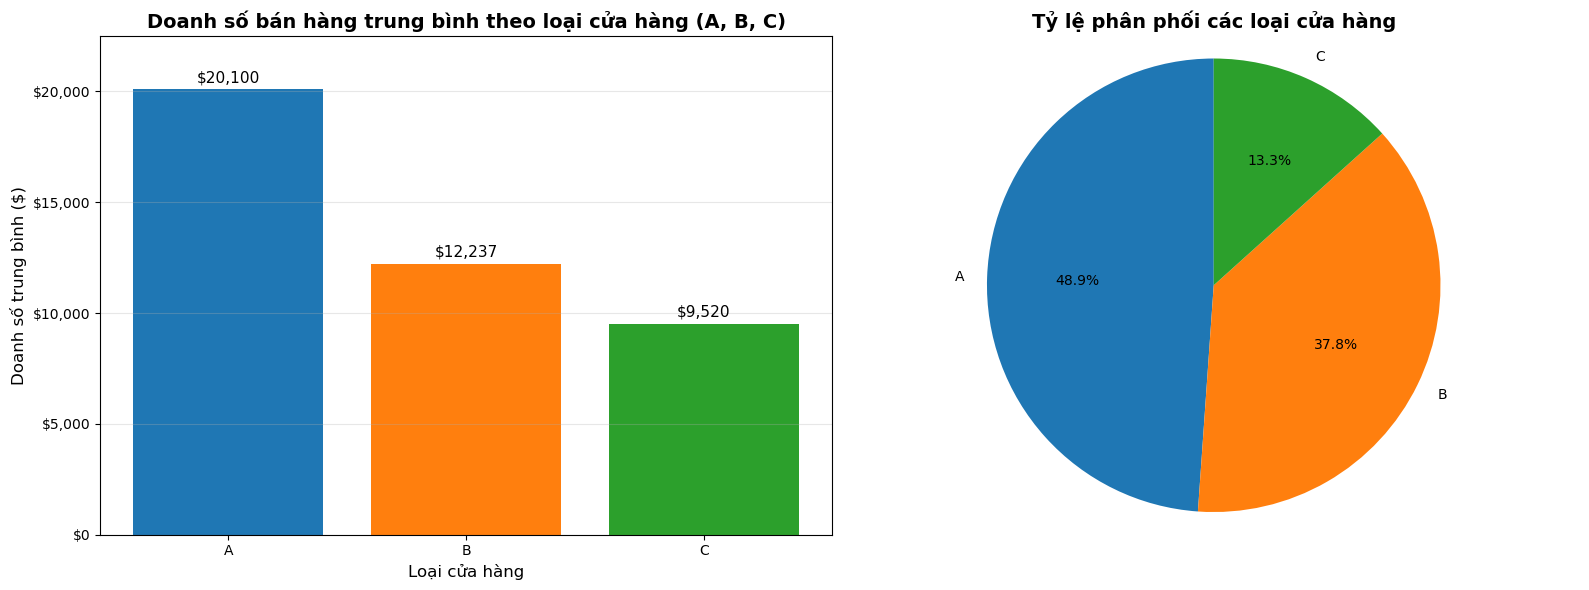

In [18]:
import matplotlib.ticker as mtick
# Tính dữ liệu
avg_sales_by_type = (
    walmart_data_train.groupby('Type')['Weekly_Sales']
    .mean()
    .sort_values(ascending=False)
)
store_type_counts = walmart_data_train.groupby('Type')['Store'].nunique().reindex(['A','B','C'])

# Vẽ 2 chart cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart Doanh số trung bình theo Type
bars = axes[0].bar(avg_sales_by_type.index, avg_sales_by_type.values,
                color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Doanh số bán hàng trung bình theo loại cửa hàng (A, B, C)',
                fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loại cửa hàng', fontsize=12)
axes[0].set_ylabel('Doanh số trung bình ($)', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, avg_sales_by_type.max() * 1.12)
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
axes[0].tick_params(axis='x', labelrotation=0)

# gắn nhãn giá trị lên từng cột
for bar, v in zip(bars, avg_sales_by_type.values):
    axes[0].annotate(f"${v:,.0f}",
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=11)

# Pie chart Tỷ lệ loại cửa hàng 
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
axes[1].pie(
    store_type_counts.values,
    labels=store_type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
axes[1].set_title('Tỷ lệ phân phối các loại cửa hàng',
                fontsize=14, fontweight='bold')
axes[1].axis('equal')  # giữ hình tròn chuẩn

plt.tight_layout()
plt.show()


**Nhận xét:**

Dựa vào thông tin 2 chart thì do cửa hàng A chiếm tỷ lệ lớn nhất **(48.89%)** vì thế doanh số trung bình cũng cao nhất **($20,099.57)**.

Tiếp đến là cửa hàng B chiếm **(37.78%)** và doạnh số trùng bình **($12,237.08)**.

Cuối cùng là cửa hàng C có tỷ lệ nhỏ nhất chiếm **(13.33%)** và doanh số trung bình **($9,519.53)**.




In [19]:
# So sánh Size trung bình của các loại cửa hàng
print("\nSO SÁNH KÍCH THƯỚC CỬA HÀNG (SIZE)")
print("-" * 60)
size_by_type = walmart_data_train.groupby('Type').agg({
    'Size': ['mean', 'min', 'max', 'std'],
    'Store': 'nunique'
}).round(2)
size_by_type.columns = ['Size_Mean', 'Size_Min', 'Size_Max', 'Size_Std', 'Số_cửa_hàng']
print(size_by_type)

# 2. So sánh số lượng phòng ban trung bình
print("\n2. SO SÁNH SỐ LƯỢNG PHÒNG BAN")
print("-" * 60)
dept_by_type = walmart_data_train.groupby('Type')['Dept'].nunique().sort_values(ascending=False)
print(dept_by_type)



SO SÁNH KÍCH THƯỚC CỬA HÀNG (SIZE)
------------------------------------------------------------
      Size_Mean  Size_Min  Size_Max  Size_Std  Số_cửa_hàng
Type                                                      
A     182231.29     39690    219622  41534.53           22
B     101818.74     34875    140167  30921.78           17
C      40535.73     39690     42988   1194.43            6

2. SO SÁNH SỐ LƯỢNG PHÒNG BAN
------------------------------------------------------------
Type
A    81
B    80
C    66
Name: Dept, dtype: int64


**Nhận xét:**

Dựa vào so sánh về kích thước (Size) và phòng ban (dept) cho thấy rằng số lượng phòng ban không phản ánh nhiều về sự chênh lệch doanh số, tuy nhiên đối với kích thước thì với Size_Mean(A) ~ 182231.29 cao hơn đáng kể so với Size_Mean(B) ~ 101818.74 và Size_Mean(C) ~ 40535.73. Điều đó phản ánh rằng diện tích lớn sẽ có nhiều sản phẩm hơn từ đó doanh số cửa hàng cao hơn

#### **2) Phòng ban nào (Department) có doanh số bán hàng trung bình cao nhất?**

In [20]:
walmart_data_train["Dept"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 40, 41, 42, 44, 45, 46, 47, 48, 49, 51, 52, 54, 55, 56,
       58, 59, 60, 67, 71, 72, 74, 77, 78, 79, 80, 81, 82, 83, 85, 87, 90,
       91, 92, 93, 94, 95, 96, 97, 98, 99, 39, 50, 43, 65], dtype=int64)

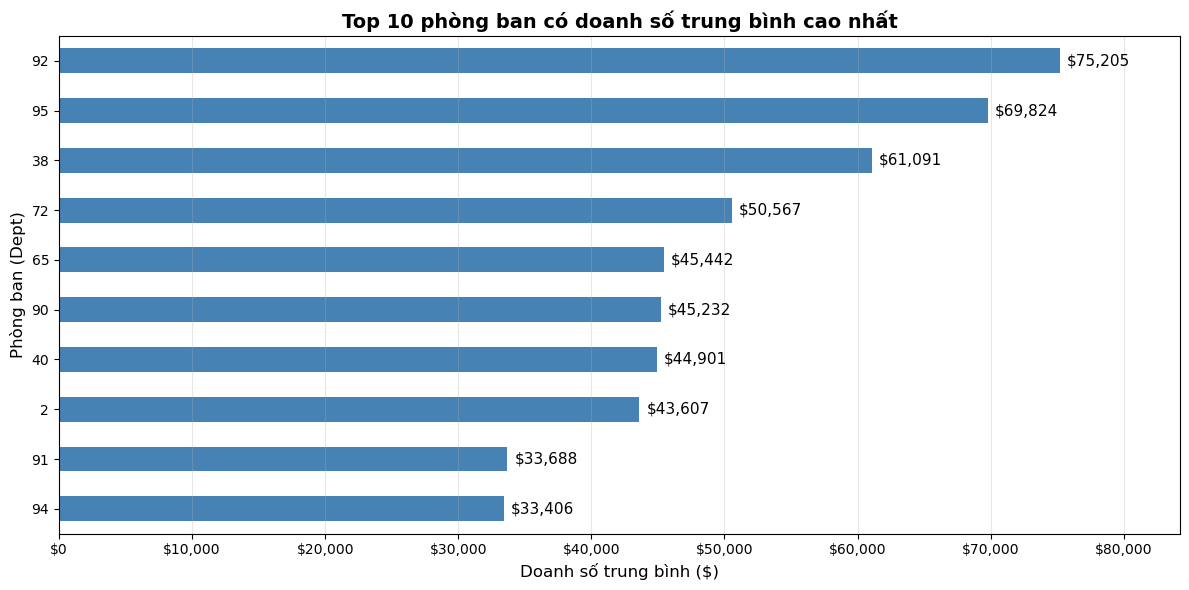

In [21]:
# Tính doanh số trung bình theo phòng ban
avg_sales_by_dept = walmart_data_train.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False)
# Visualize Top 10
plt.figure(figsize=(12, 6))
avg_sales_by_dept.head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 phòng ban có doanh số trung bình cao nhất', fontsize=14, fontweight='bold')
plt.xlabel('Doanh số trung bình ($)', fontsize=12)
plt.ylabel('Phòng ban (Dept)', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

ax = plt.gca()
# Định dạng trục X dạng tiền tệ và chừa chỗ cho nhãn
vals = avg_sales_by_dept.head(10).values
ax.set_xlim(0, max(vals) * 1.12)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Gắn nhãn giá trị ở cuối mỗi cột (barh)
for bar, v in zip(ax.patches, vals):
    ax.annotate(f"${v:,.0f}",
                xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                xytext=(5, 0), textcoords="offset points",
                va='center', ha='left', fontsize=11)

plt.tight_layout()
plt.show()


**Nhận xét:**
- Phòng ban 92 có doanh số trung bình cao nhất: $75,204.87
- Top 3 phòng ban hàng đầu: [92, 95, 38]
- Có sự chênh lệch lớn giữa các phòng ban, cho thấy một số ngành hàng quan trọng hơn về mặt doanh thu

#### **3) Tổng doanh số bán hàng hàng tháng qua các năm (2010, 2011, 2012) có xu hướng như thế nào?**


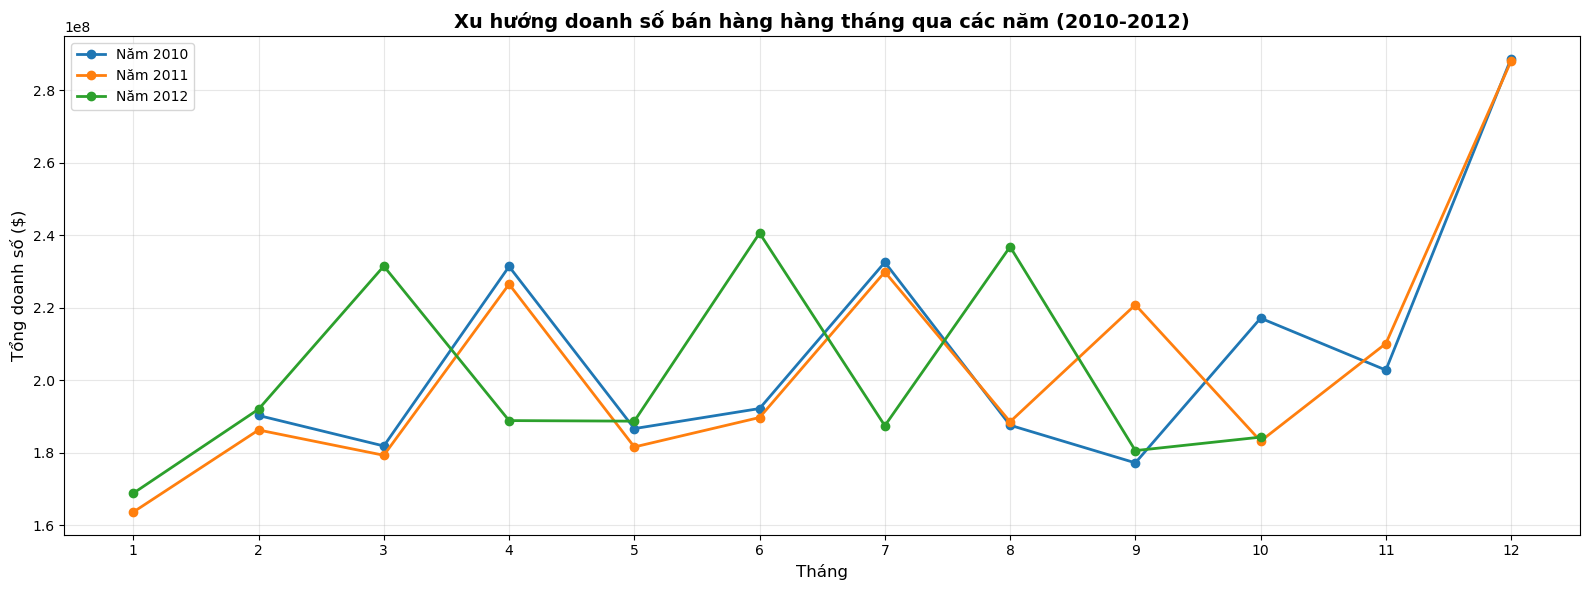

In [22]:
# Tính tổng doanh số theo tháng và năm
monthly_sales = walmart_data_train.groupby(['Year', 'Month'])['Weekly_Sales'].sum().reset_index()

# Tạo cột Year-Month để vẽ đồ thị dễ hơn
monthly_sales['Year_Month'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2)

# Visualize
plt.figure(figsize=(16, 6))
for year in monthly_sales['Year'].unique():
    year_data = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(year_data['Month'], year_data['Weekly_Sales'], marker='o', label=f'Năm {year}', linewidth=2)

plt.title('Xu hướng doanh số bán hàng hàng tháng qua các năm (2010-2012)', fontsize=14, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Tổng doanh số ($)', fontsize=12)
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Phân tích xu hướng:**

Tổng doanh số năm 2010: $2,288,886,120.41

Tổng doanh số năm 2011: $2,448,200,007.35

Tổng doanh số năm 2012: $2,000,132,859.35

**Nhận xét:**
- Doanh số có xu hướng tăng mạnh vào cuối năm (tháng 11-12) do mùa lễ hội
- Doanh số thấp nhất thường rơi vào đầu năm (tháng 1-2)
- Có sự tăng trưởng ổn định qua các năm

#### **4) Cửa hàng và phòng ban cụ thể nào tạo ra doanh số cao nhất?**


C:\Users\luong\AppData\Local\Temp\ipykernel_17700\2311259519.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10['Store_Dept'] = 'Store ' + top_10['Store'].astype(str) + ' - Dept ' + top_10['Dept'].astype(str)


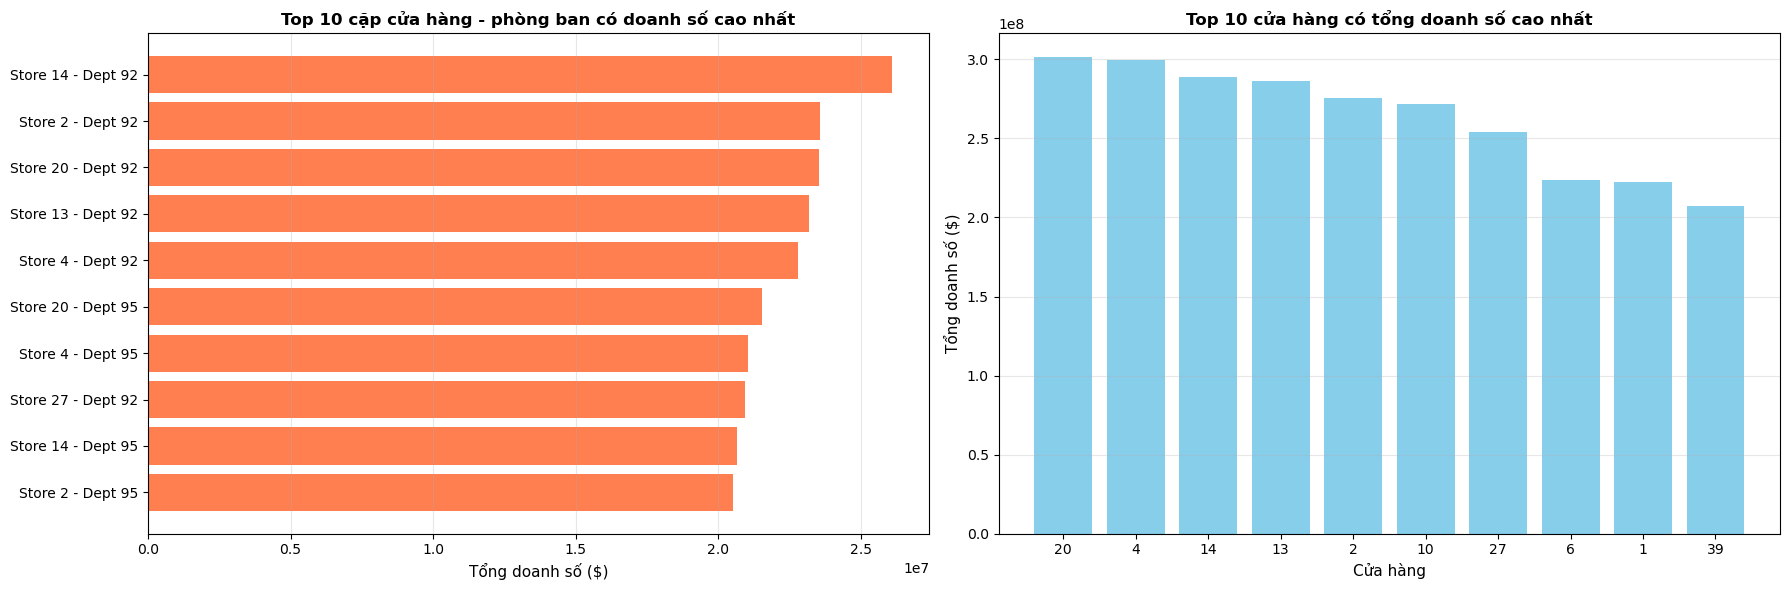

In [23]:
# Tính tổng doanh số theo Store và Dept
store_dept_sales = walmart_data_train.groupby(['Store', 'Dept'])['Weekly_Sales'].sum().reset_index()
store_dept_sales = store_dept_sales.sort_values('Weekly_Sales', ascending=False)

# print("Top 10 cặp cửa hàng - phòng ban có doanh số cao nhất:\n")
# print(store_dept_sales.head(10))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 10 Store-Dept combinations
top_10 = store_dept_sales.head(10)
top_10['Store_Dept'] = 'Store ' + top_10['Store'].astype(str) + ' - Dept ' + top_10['Dept'].astype(str)
axes[0].barh(top_10['Store_Dept'], top_10['Weekly_Sales'], color='coral')
axes[0].set_title('Top 10 cặp cửa hàng - phòng ban có doanh số cao nhất', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tổng doanh số ($)', fontsize=11)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Top Stores
top_stores = walmart_data_train.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)
axes[1].bar(top_stores.index.astype(str), top_stores.values, color='skyblue')
axes[1].set_title('Top 10 cửa hàng có tổng doanh số cao nhất', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cửa hàng', fontsize=11)
axes[1].set_ylabel('Tổng doanh số ($)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()



**Nhận xét:**
- Cửa hàng 14 - Phòng ban 92 có doanh số cao nhất: $26,101,497.71
- Cửa hàng 20 có tổng doanh số cao nhất trong toàn hệ thống: $301,397,792.46
- Sự tập trung doanh số vào một số cặp Store-Dept cho thấy cần tập trung nguồn lực vào các điểm bán hiệu quả

### **2. Phân tích tương quan**

#### **1) Sự thay đổi về nhiệt độ (Temperature) ảnh hưởng như thế nào đến doanh số bán hàng hàng tuần?**

C:\Users\luong\AppData\Local\Temp\ipykernel_17700\3086692217.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_stats = walmart_data_train.groupby('Temp_Range')['Weekly_Sales'].agg(['mean', 'median', 'count'])
C:\Users\luong\AppData\Local\Temp\ipykernel_17700\3086692217.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_avg = walmart_data_train.groupby('Temp_Range')['Weekly_Sales'].mean().sort_values(ascending=False)
C:\Users\luong\AppData\Local\Temp\ipykernel_17700\3086692217.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


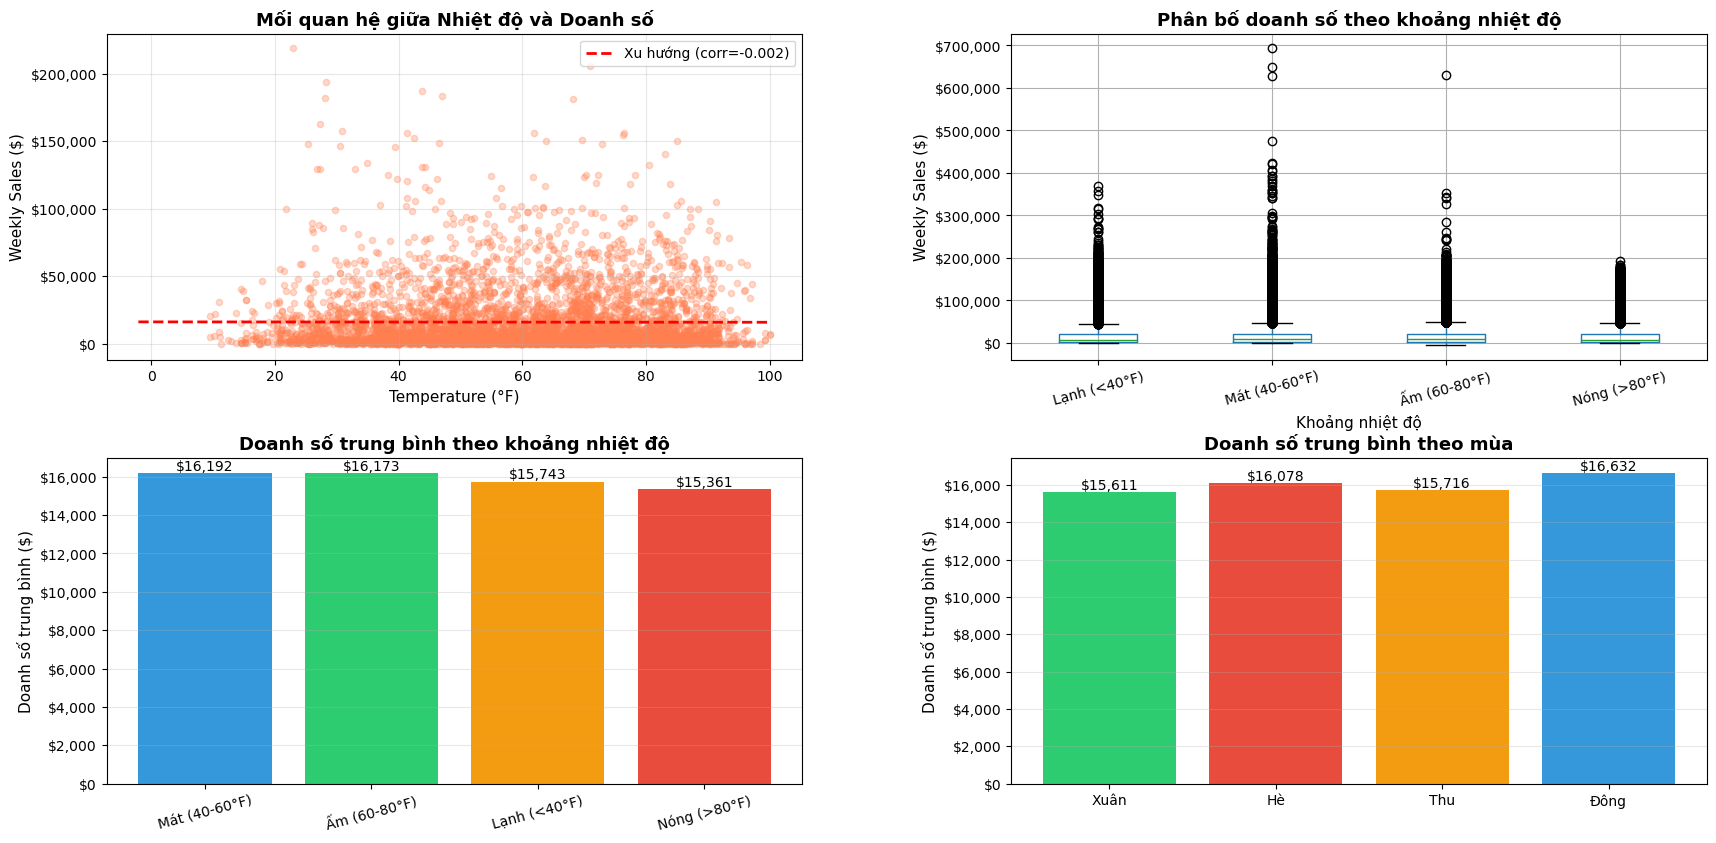

In [24]:
# PHÂN TÍCH: Ảnh hưởng của Temperature đến Weekly_Sales

# 1. Tính correlation
temp_sales_corr = walmart_data_train[['Temperature', 'Weekly_Sales']].corr().iloc[0, 1]

# 2. Phân nhóm nhiệt độ
walmart_data_train['Temp_Range'] = pd.cut(walmart_data_train['Temperature'], 
                                     bins=[0, 40, 60, 80, 100],
                                     labels=['Lạnh (<40°F)', 'Mát (40-60°F)', 
                                            'Ấm (60-80°F)', 'Nóng (>80°F)'])

# 3. Thống kê doanh số theo khoảng nhiệt độ
temp_stats = walmart_data_train.groupby('Temp_Range')['Weekly_Sales'].agg(['mean', 'median', 'count'])

# 4. Phân tích theo mùa (dựa vào tháng)
walmart_data_train['Season'] = walmart_data_train['Month'].map({
    12: 'Đông', 1: 'Đông', 2: 'Đông',
    3: 'Xuân', 4: 'Xuân', 5: 'Xuân',
    6: 'Hè', 7: 'Hè', 8: 'Hè',
    9: 'Thu', 10: 'Thu', 11: 'Thu'
})

season_temp_sales = walmart_data_train.groupby('Season').agg({
    'Temperature': 'mean',
    'Weekly_Sales': 'mean'
}).round(2)

# VISUALIZATION
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Chart 1: Scatter plot Temperature vs Weekly_Sales
ax1 = fig.add_subplot(gs[0, 0])
sample = walmart_data_train.sample(n=min(5000, len(walmart_data_train)), random_state=42)
ax1.scatter(sample['Temperature'], sample['Weekly_Sales'], alpha=0.3, s=20, color='coral')
ax1.set_title('Mối quan hệ giữa Nhiệt độ và Doanh số', fontsize=13, fontweight='bold')
ax1.set_xlabel('Temperature (°F)', fontsize=11)
ax1.set_ylabel('Weekly Sales ($)', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Thêm đường xu hướng
z = np.polyfit(walmart_data_train['Temperature'].dropna(), 
               walmart_data_train.loc[walmart_data_train['Temperature'].notna(), 'Weekly_Sales'], 1)
p = np.poly1d(z)
temp_range = np.linspace(walmart_data_train['Temperature'].min(), 
                         walmart_data_train['Temperature'].max(), 100)
ax1.plot(temp_range, p(temp_range), "r--", linewidth=2, label=f'Xu hướng (corr={temp_sales_corr:.3f})')
ax1.legend()

# Chart 2: Box plot doanh số theo khoảng nhiệt độ
ax2 = fig.add_subplot(gs[0, 1])
walmart_data_train.boxplot(column='Weekly_Sales', by='Temp_Range', ax=ax2)
ax2.set_title('Phân bố doanh số theo khoảng nhiệt độ', fontsize=13, fontweight='bold')
ax2.set_xlabel('Khoảng nhiệt độ', fontsize=11)
ax2.set_ylabel('Weekly Sales ($)', fontsize=11)
ax2.tick_params(axis='x', rotation=15)
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.suptitle('')

# Chart 3: Bar chart doanh số trung bình theo khoảng nhiệt độ
ax3 = fig.add_subplot(gs[1, 0])
temp_avg = walmart_data_train.groupby('Temp_Range')['Weekly_Sales'].mean().sort_values(ascending=False)
bars = ax3.bar(range(len(temp_avg)), temp_avg.values, 
              color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'])
ax3.set_xticks(range(len(temp_avg)))
ax3.set_xticklabels(temp_avg.index, rotation=15)
ax3.set_title('Doanh số trung bình theo khoảng nhiệt độ', fontsize=13, fontweight='bold')
ax3.set_ylabel('Doanh số trung bình ($)', fontsize=11)
ax3.grid(axis='y', alpha=0.3)
ax3.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

for bar, v in zip(bars, temp_avg.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'${v:,.0f}', ha='center', va='bottom', fontsize=10)

# Chart 4: Doanh số theo mùa
ax4 = fig.add_subplot(gs[1, 1])
season_order = ['Xuân', 'Hè', 'Thu', 'Đông']
season_sales = walmart_data_train.groupby('Season')['Weekly_Sales'].mean().reindex(season_order)
bars = ax4.bar(season_sales.index, season_sales.values, 
              color=['#2ecc71', '#e74c3c', '#f39c12', '#3498db'])
ax4.set_title('Doanh số trung bình theo mùa', fontsize=13, fontweight='bold')
ax4.set_ylabel('Doanh số trung bình ($)', fontsize=11)
ax4.grid(axis='y', alpha=0.3)
ax4.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

for bar, v in zip(bars, season_sales.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'${v:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


**Nhận xét:**

- Hệ số tương quan rất yếu (-0.0023), cho thấy nhiệt độ không làm giảm nhu cầu mua hàng nên doanh số không ảnh hưởng nhiều.
- Tuy nhiên nếu phân chia mức nhiệt độ thành các mùa hay khoảng nhiệt độ thì mùa Đông nhỉnh hơn các mùa khác do có ngày lễ cuối năm (yếu tố lễ hội quan trọng đến doanh số
- Nhiệt độ có thể ảnh hưởng gián tiếp qua hành vi mua sắm theo mùa.

> Đây được xem là cột yếu tố kinh tế vĩ mô của khách hàng khi nhiệt độ gia tăng lên khách hàng ít di chuyển nên lượng hàng hóa bán ít làm ảnh hưởng đến doanh số bán hàng.

#### **2) Mức độ thất nghiệp (Unemployment) có tác động gì đến doanh số bán hàng hàng tuần?**
 

C:\Users\luong\AppData\Local\Temp\ipykernel_17700\914438884.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unemp_stats = walmart_data_train.groupby('Unemp_Level')['Weekly_Sales'].agg(['mean', 'median', 'count'])
C:\Users\luong\AppData\Local\Temp\ipykernel_17700\914438884.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unemp_avg = walmart_data_train.groupby('Unemp_Level')['Weekly_Sales'].mean()
C:\Users\luong\AppData\Local\Temp\ipykernel_17700\914438884.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


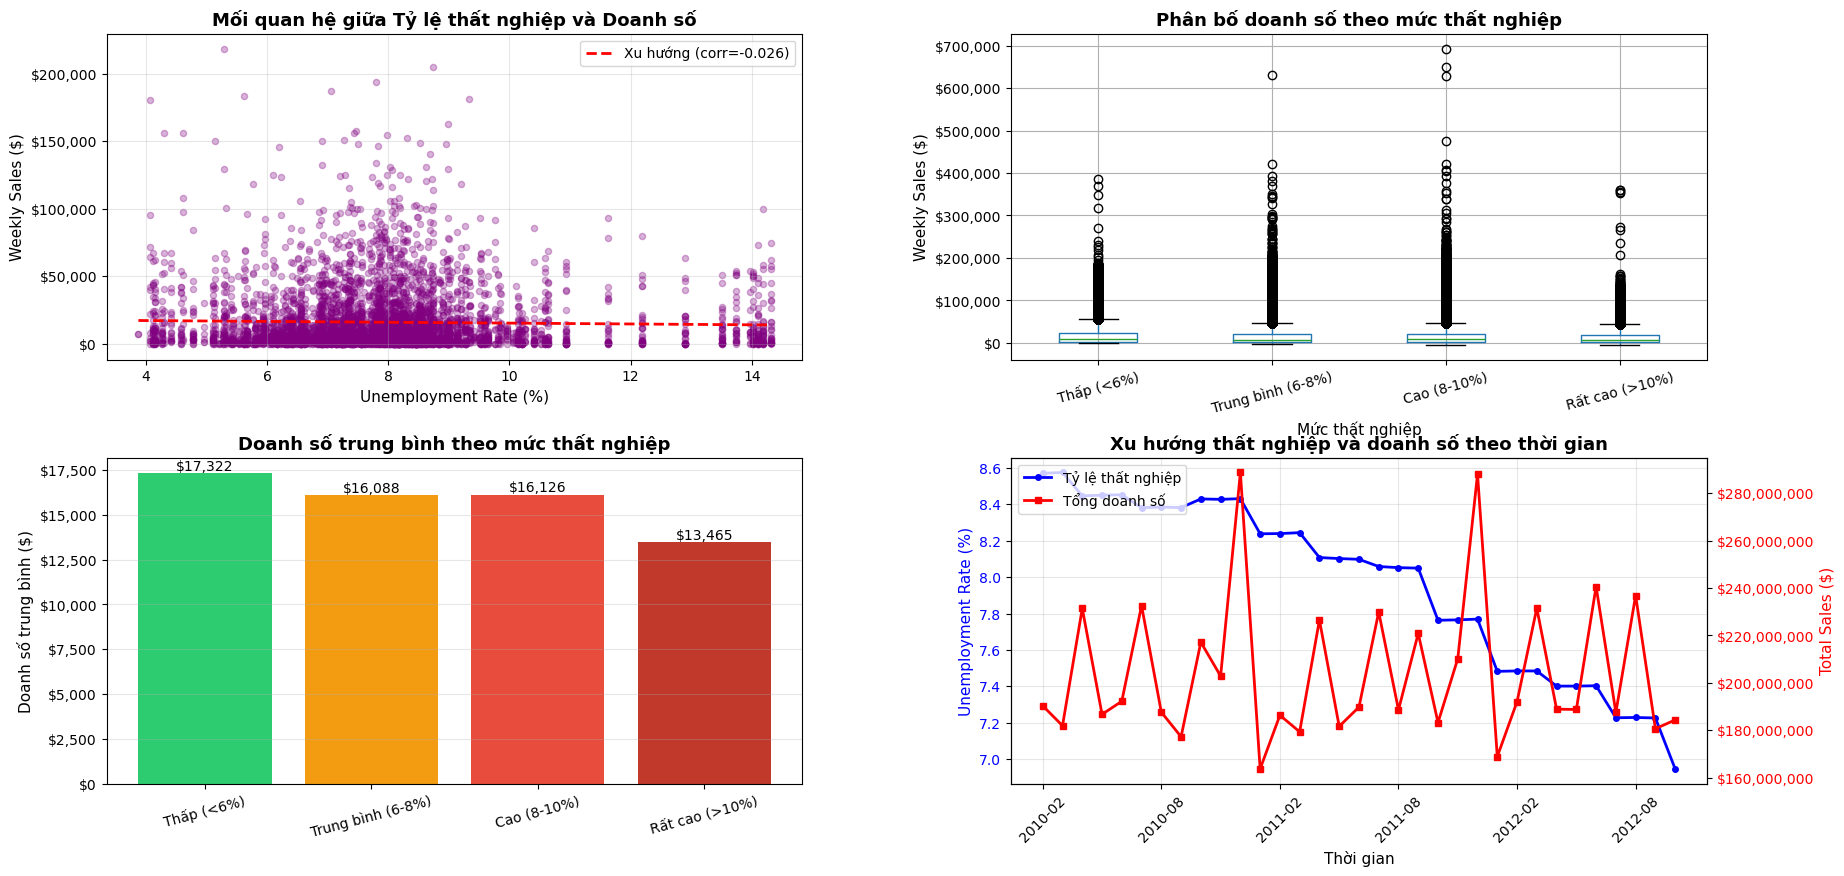

In [25]:
# PHÂN TÍCH: Ảnh hưởng của Unemployment đến Weekly_Sales

# print("="*80)
# print("ẢNH HƯỞNG CỦA TỶ LỆ THẤT NGHIỆP ĐẾN DOANH SỐ")
# print("="*80)

# # 1. Tính correlation
unemp_sales_corr = walmart_data_train[['Unemployment', 'Weekly_Sales']].corr().iloc[0, 1]
# print(f"\nHệ số tương quan Unemployment vs Weekly_Sales: {unemp_sales_corr:.4f}")

# # 2. Phân nhóm unemployment
walmart_data_train['Unemp_Level'] = pd.cut(walmart_data_train['Unemployment'], 
                                    bins=[0, 6, 8, 10, 15],
                                    labels=['Thấp (<6%)', 'Trung bình (6-8%)', 
                                            'Cao (8-10%)', 'Rất cao (>10%)'])

# 3. Thống kê
unemp_stats = walmart_data_train.groupby('Unemp_Level')['Weekly_Sales'].agg(['mean', 'median', 'count'])
# print("\nDoanh số trung bình theo mức thất nghiệp:")
# print(unemp_stats)

# # 4. Phân tích theo năm
yearly_unemp = walmart_data_train.groupby('Year').agg({
    'Unemployment': 'mean',
    'Weekly_Sales': 'mean'
    }).round(2)
# print("\nTỷ lệ thất nghiệp và doanh số trung bình theo năm:")
# print(yearly_unemp)

# # 5. Phân tích theo Type
type_unemp = walmart_data_train.groupby('Type').agg({
    'Unemployment': 'mean',
    'Weekly_Sales': 'mean'
    }).round(2)
# print("\nTỷ lệ thất nghiệp và doanh số trung bình theo Type:")
# print(type_unemp)

# VISUALIZATION
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Chart 1: Scatter plot Unemployment vs Weekly_Sales
ax1 = fig.add_subplot(gs[0, 0])
sample = walmart_data_train.sample(n=min(5000, len(walmart_data_train)), random_state=42)
ax1.scatter(sample['Unemployment'], sample['Weekly_Sales'], alpha=0.3, s=20, color='purple')
ax1.set_title('Mối quan hệ giữa Tỷ lệ thất nghiệp và Doanh số', fontsize=13, fontweight='bold')
ax1.set_xlabel('Unemployment Rate (%)', fontsize=11)
ax1.set_ylabel('Weekly Sales ($)', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Thêm đường xu hướng
z = np.polyfit(walmart_data_train['Unemployment'].dropna(), 
            walmart_data_train.loc[walmart_data_train['Unemployment'].notna(), 'Weekly_Sales'], 1)
p = np.poly1d(z)
unemp_range = np.linspace(walmart_data_train['Unemployment'].min(), 
                        walmart_data_train['Unemployment'].max(), 100)
ax1.plot(unemp_range, p(unemp_range), "r--", linewidth=2, 
        label=f'Xu hướng (corr={unemp_sales_corr:.3f})')
ax1.legend()

# Chart 2: Box plot doanh số theo mức unemployment
ax2 = fig.add_subplot(gs[0, 1])
walmart_data_train.boxplot(column='Weekly_Sales', by='Unemp_Level', ax=ax2)
ax2.set_title('Phân bố doanh số theo mức thất nghiệp', fontsize=13, fontweight='bold')
ax2.set_xlabel('Mức thất nghiệp', fontsize=11)
ax2.set_ylabel('Weekly Sales ($)', fontsize=11)
ax2.tick_params(axis='x', rotation=15)
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.suptitle('')

# Chart 3: Doanh số trung bình theo mức unemployment
ax3 = fig.add_subplot(gs[1, 0])
unemp_avg = walmart_data_train.groupby('Unemp_Level')['Weekly_Sales'].mean()
bars = ax3.bar(range(len(unemp_avg)), unemp_avg.values, 
            color=['#2ecc71', '#f39c12', '#e74c3c', '#c0392b'])
ax3.set_xticks(range(len(unemp_avg)))
ax3.set_xticklabels(unemp_avg.index, rotation=15)
ax3.set_title('Doanh số trung bình theo mức thất nghiệp', fontsize=13, fontweight='bold')
ax3.set_ylabel('Doanh số trung bình ($)', fontsize=11)
ax3.grid(axis='y', alpha=0.3)
ax3.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

for bar, v in zip(bars, unemp_avg.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'${v:,.0f}', ha='center', va='bottom', fontsize=10)

# Chart 4: Biểu đồ kép - Unemployment và Sales theo thời gian
ax4 = fig.add_subplot(gs[1, 1])
monthly_data = walmart_data_train.groupby(['Year', 'Month']).agg({
    'Unemployment': 'mean',
    'Weekly_Sales': 'sum'
}).reset_index()
monthly_data['Period'] = monthly_data['Year'].astype(str) + '-' + monthly_data['Month'].astype(str).str.zfill(2)

ax4_twin = ax4.twinx()
line1 = ax4.plot(range(len(monthly_data)), monthly_data['Unemployment'], 
                'b-o', linewidth=2, markersize=4, label='Tỷ lệ thất nghiệp')
line2 = ax4_twin.plot(range(len(monthly_data)), monthly_data['Weekly_Sales'], 
                    'r-s', linewidth=2, markersize=4, label='Tổng doanh số')

ax4.set_title('Xu hướng thất nghiệp và doanh số theo thời gian', fontsize=13, fontweight='bold')
ax4.set_xlabel('Thời gian', fontsize=11)
ax4.set_ylabel('Unemployment Rate (%)', fontsize=11, color='b')
ax4_twin.set_ylabel('Total Sales ($)', fontsize=11, color='r')
ax4.tick_params(axis='y', labelcolor='b')
ax4_twin.tick_params(axis='y', labelcolor='r')
ax4.grid(True, alpha=0.3)
ax4.set_xticks(range(0, len(monthly_data), 6))
ax4.set_xticklabels(monthly_data['Period'][::6], rotation=45)
ax4_twin.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Kết hợp legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax4.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()


**Nhận xét:**
- Hệ số tương quan âm rất yếu (-0.0259), cho thấy tỷ lệ thất nghiệp làm giảm số lượng mua nên sẽ có xu hướng giảm nhưng không lớn.
- Tuy nhiên với tỷ lệ thất nghiệp rất cao (>10%) có sự biến đổi về doanh số so với các tỷ lệ khác. 
- Đối với năm 2010 đến 2012 tỷ lệ thất nghiệp luôn giảm nhưng doanh số không thay đổi nhiều, cho thấy vấn đề thất nghiệp không là yếu tố ảnh hưởng đến doanh thu của các cửa hàng.

> Đây được xem là cột yếu tố kinh tế vĩ mô của khách hàng khi tỷ lệ thất nghiệp có làm cho người mua giảm nhu cầu mua hàng làm doanh số lung lay hay không.


#### **3) Giá nhiên liệu (Fuel Price) có mối tương quan như thế nào với doanh số bán hàng?**

C:\Users\luong\AppData\Local\Temp\ipykernel_17700\849930191.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fuel_stats = walmart_data_train.groupby('Fuel_Level')['Weekly_Sales'].agg(['mean', 'median', 'count'])
C:\Users\luong\AppData\Local\Temp\ipykernel_17700\849930191.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fuel_avg = walmart_data_train.groupby('Fuel_Level')['Weekly_Sales'].mean()
C:\Users\luong\AppData\Local\Temp\ipykernel_17700\849930191.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


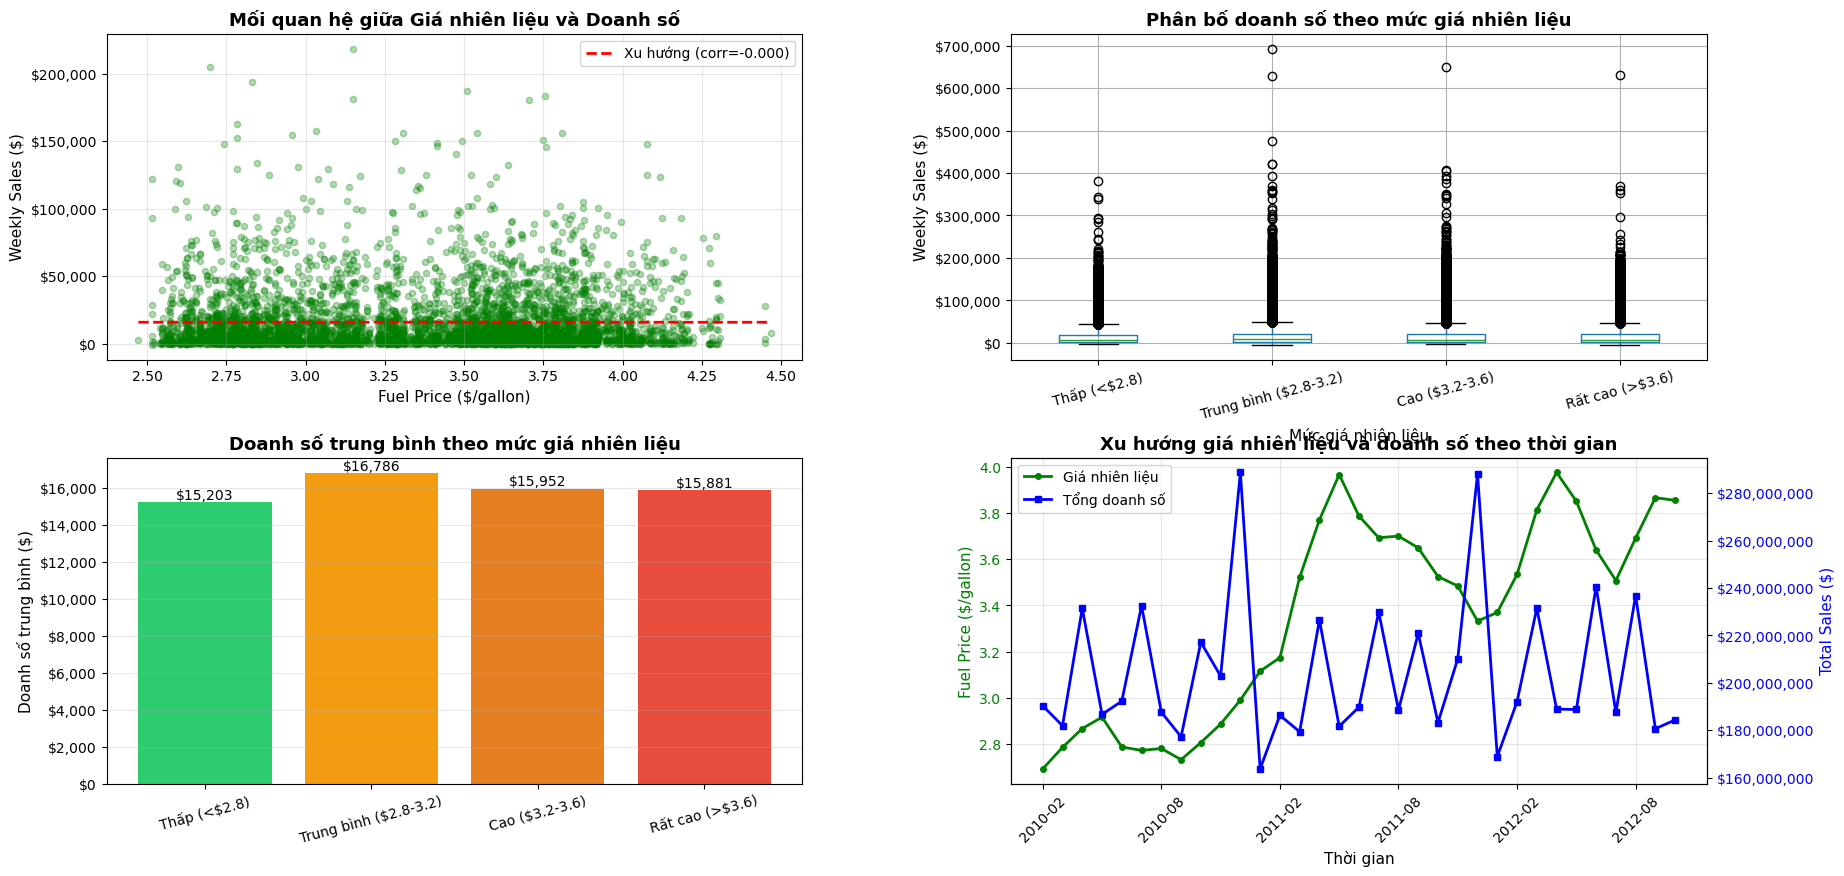

In [26]:
# # PHÂN TÍCH: Ảnh hưởng của Fuel_Price đến Weekly_Sales

# print("="*80)
# print("ẢNH HƯỞNG CỦA GIÁ NHIÊN LIỆU ĐẾN DOANH SỐ")
# print("="*80)

# # 1. Tính correlation
fuel_sales_corr = walmart_data_train[['Fuel_Price', 'Weekly_Sales']].corr().iloc[0, 1]
# print(f"\nHệ số tương quan Fuel_Price vs Weekly_Sales: {fuel_sales_corr:.4f}")

# # 2. Phân nhóm Fuel_Price
walmart_data_train['Fuel_Level'] = pd.cut(walmart_data_train['Fuel_Price'], 
                                        bins=[0, 2.8, 3.2, 3.6, 5.0],
                                        labels=['Thấp (<$2.8)', 'Trung bình ($2.8-3.2)', 
                                                'Cao ($3.2-3.6)', 'Rất cao (>$3.6)'])

# # 3. Thống kê
fuel_stats = walmart_data_train.groupby('Fuel_Level')['Weekly_Sales'].agg(['mean', 'median', 'count'])
# print("\nDoanh số trung bình theo mức giá nhiên liệu:")
# print(fuel_stats)

# # 4. Phân tích theo thời gian
yearly_fuel = walmart_data_train.groupby('Year').agg({
        'Fuel_Price': 'mean',
        'Weekly_Sales': 'mean' 
        }).round(2)
# print("\nGiá nhiên liệu và doanh số trung bình theo năm:")
# print(yearly_fuel)

# # 5. Thống kê tổng quát về Fuel_Price
# print("\nThống kê mô tả về Fuel_Price:")
# print(walmart_data_train['Fuel_Price'].describe())

# VISUALIZATION
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Chart 1: Scatter plot Fuel_Price vs Weekly_Sales
ax1 = fig.add_subplot(gs[0, 0])
sample = walmart_data_train.sample(n=min(5000, len(walmart_data_train)), random_state=42)
ax1.scatter(sample['Fuel_Price'], sample['Weekly_Sales'], alpha=0.3, s=20, color='green')
ax1.set_title('Mối quan hệ giữa Giá nhiên liệu và Doanh số', fontsize=13, fontweight='bold')
ax1.set_xlabel('Fuel Price ($/gallon)', fontsize=11)
ax1.set_ylabel('Weekly Sales ($)', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Thêm đường xu hướng
z = np.polyfit(walmart_data_train['Fuel_Price'].dropna(), 
                walmart_data_train.loc[walmart_data_train['Fuel_Price'].notna(), 'Weekly_Sales'], 1)
p = np.poly1d(z)
fuel_range = np.linspace(walmart_data_train['Fuel_Price'].min(), 
                        walmart_data_train['Fuel_Price'].max(), 100)
ax1.plot(fuel_range, p(fuel_range), "r--", linewidth=2, 
        label=f'Xu hướng (corr={fuel_sales_corr:.3f})')
ax1.legend()

# Chart 2: Box plot doanh số theo mức fuel price
ax2 = fig.add_subplot(gs[0, 1])
walmart_data_train.boxplot(column='Weekly_Sales', by='Fuel_Level', ax=ax2)
ax2.set_title('Phân bố doanh số theo mức giá nhiên liệu', fontsize=13, fontweight='bold')
ax2.set_xlabel('Mức giá nhiên liệu', fontsize=11)
ax2.set_ylabel('Weekly Sales ($)', fontsize=11)
ax2.tick_params(axis='x', rotation=15)
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.suptitle('')

# Chart 3: Doanh số trung bình theo mức giá nhiên liệu
ax3 = fig.add_subplot(gs[1, 0])
fuel_avg = walmart_data_train.groupby('Fuel_Level')['Weekly_Sales'].mean()
bars = ax3.bar(range(len(fuel_avg)), fuel_avg.values, 
                color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'])
ax3.set_xticks(range(len(fuel_avg)))
ax3.set_xticklabels(fuel_avg.index, rotation=15)
ax3.set_title('Doanh số trung bình theo mức giá nhiên liệu', fontsize=13, fontweight='bold')
ax3.set_ylabel('Doanh số trung bình ($)', fontsize=11)
ax3.grid(axis='y', alpha=0.3)
ax3.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

for bar, v in zip(bars, fuel_avg.values):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
        f'${v:,.0f}', ha='center', va='bottom', fontsize=10)

# Chart 4: Biểu đồ kép - Fuel Price và Sales theo thời gian
ax4 = fig.add_subplot(gs[1, 1])
monthly_data = walmart_data_train.groupby(['Year', 'Month']).agg({
        'Fuel_Price': 'mean',
        'Weekly_Sales': 'sum'
}).reset_index()
monthly_data['Period'] = monthly_data['Year'].astype(str) + '-' + monthly_data['Month'].astype(str).str.zfill(2)

ax4_twin = ax4.twinx()
line1 = ax4.plot(range(len(monthly_data)), monthly_data['Fuel_Price'], 
                'g-o', linewidth=2, markersize=4, label='Giá nhiên liệu')
line2 = ax4_twin.plot(range(len(monthly_data)), monthly_data['Weekly_Sales'], 
                'b-s', linewidth=2, markersize=4, label='Tổng doanh số')

ax4.set_title('Xu hướng giá nhiên liệu và doanh số theo thời gian', fontsize=13, fontweight='bold')
ax4.set_xlabel('Thời gian', fontsize=11)
ax4.set_ylabel('Fuel Price ($/gallon)', fontsize=11, color='g')
ax4_twin.set_ylabel('Total Sales ($)', fontsize=11, color='b')
ax4.tick_params(axis='y', labelcolor='g')
ax4_twin.tick_params(axis='y', labelcolor='b')
ax4.grid(True, alpha=0.3)
ax4.set_xticks(range(0, len(monthly_data), 6))
ax4.set_xticklabels(monthly_data['Period'][::6], rotation=45)
ax4_twin.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Kết hợp legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax4.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()


**Nhận xét:**

- Hệ số xu hướng gần như là không có (corr = 0.000), thậm chí có các giá trị outlier ở mức giá nguyên liệu tăng cao. Điều này cho thấy sự gia tăng về giá nguyên liệu không làm giảm nhu cầu mua hàng của khách hàng.

> Đây được xem là cột yếu tố kinh tế vĩ mô của khách hàng khi mức giá nguyên liệu không làm cho khách hàng ở xa hay ở gần giảm nhu cầu mua hàng.

### **3. Phân tích so sánh**

#### **1) Doanh số bán hàng hàng tuần trong các tuần có ngày lễ (Holiday) có cao hơn đáng kể so với các tuần không có ngày lễ (Non-Holiday) hay không?**


C:\Users\luong\AppData\Local\Temp\ipykernel_17700\1964743411.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


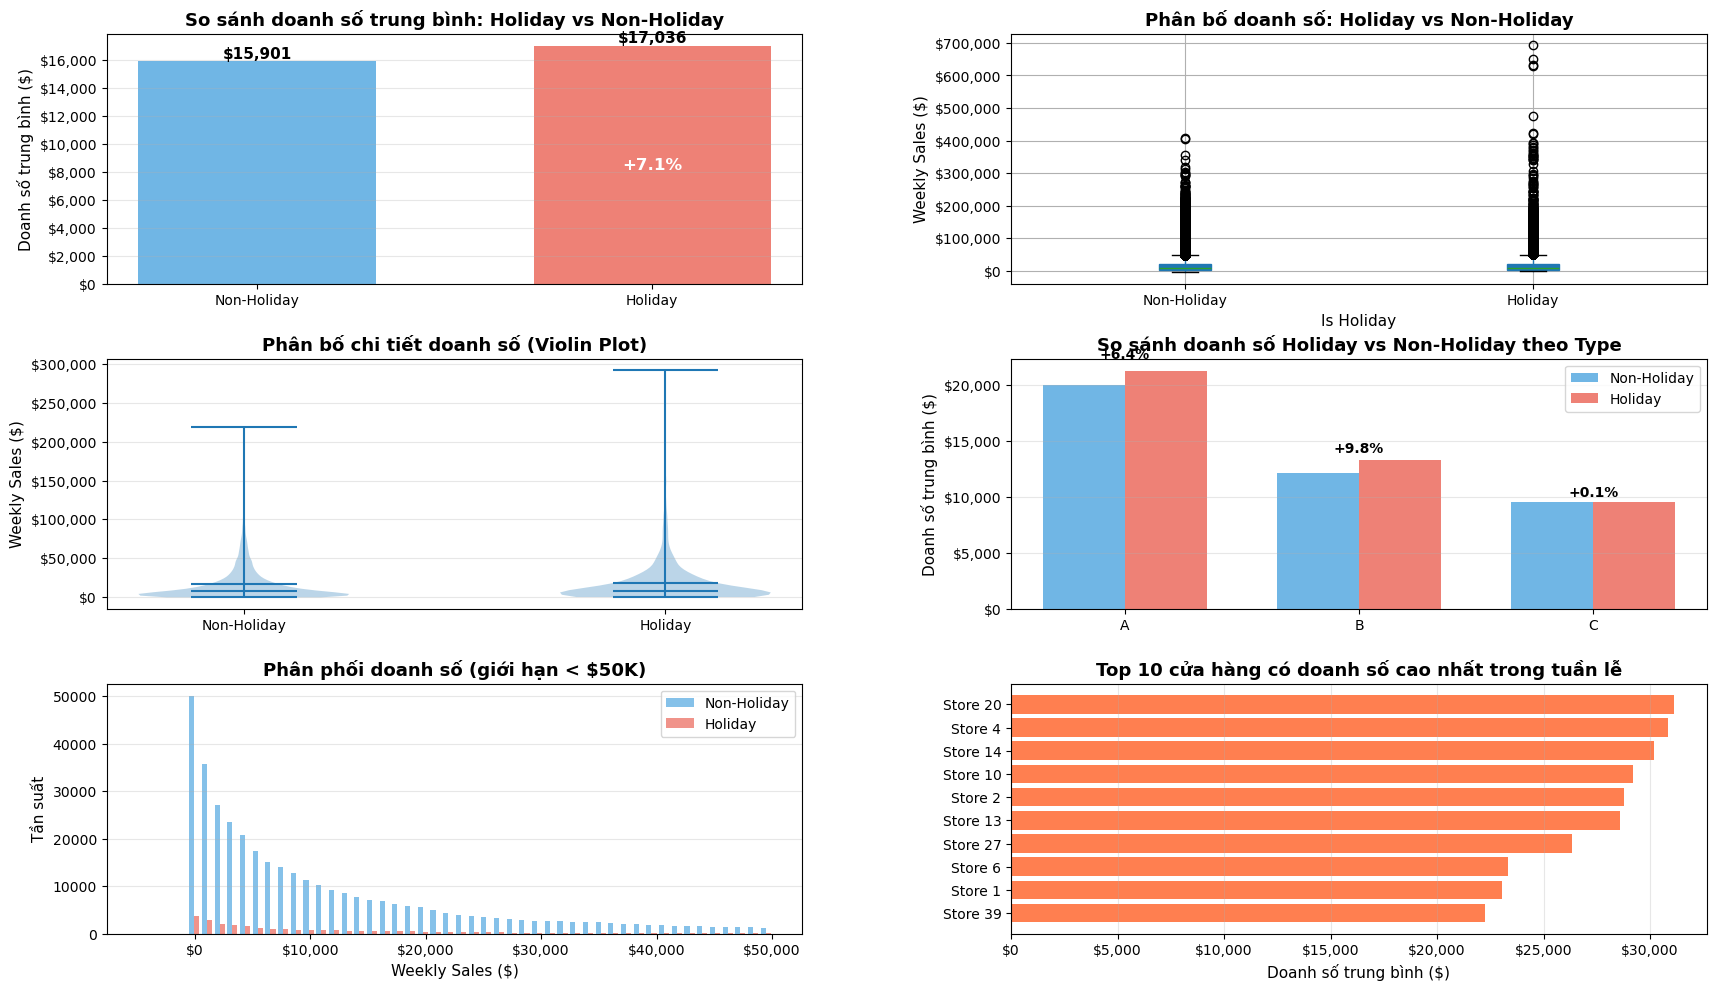


KẾT LUẬN

✓ Doanh số trong tuần LỄ CAO HƠN 7.13% so với tuần thường
  → Ngày lễ có tác động TÍCH CỰC đến doanh số

✓ Tất cả các Type đều có xu hướng tương tự

✓ P-value = 1.0912e-16 < 0.05 → Có ý nghĩa thống kê


In [27]:
# PHÂN TÍCH SO SÁNH: Holiday vs Non-Holiday

# print("="*80)
# print("SO SÁNH DOANH SỐ: TUẦN CÓ NGÀY LỄ VS TUẦN THƯỜNG")
# print("="*80)

# 1. Thống kê cơ bản
holiday_stats = walmart_data_train.groupby('IsHoliday')['Weekly_Sales'].agg(['mean', 'median', 'std', 'count'])
holiday_stats.index = ['Non-Holiday', 'Holiday']
# print("\nThống kê doanh số theo IsHoliday:")
# print(holiday_stats)

# 2. So sánh phần trăm
non_holiday_mean = holiday_stats.loc['Non-Holiday', 'mean']
holiday_mean = holiday_stats.loc['Holiday', 'mean']
diff_pct = ((holiday_mean - non_holiday_mean) / non_holiday_mean) * 100

# print(f"\nSo sánh:")
# print(f"   Doanh số trung bình tuần THƯỜNG: ${non_holiday_mean:,.2f}")
# print(f"   Doanh số trung bình tuần LỄ: ${holiday_mean:,.2f}")
# print(f"   Chênh lệch: {diff_pct:+.2f}%")

# 3. Phân tích theo Type
# print("\n" + "-"*80)
# print("Doanh số Holiday vs Non-Holiday theo từng Type:")
type_holiday_comparison = walmart_data_train.groupby(['Type', 'IsHoliday'])['Weekly_Sales'].mean().unstack()
type_holiday_comparison.columns = ['Non-Holiday', 'Holiday']
type_holiday_comparison['Difference (%)'] = ((type_holiday_comparison['Holiday'] - type_holiday_comparison['Non-Holiday']) / type_holiday_comparison['Non-Holiday'] * 100).round(2)
# print(type_holiday_comparison)

# 4. T-test để kiểm tra sự khác biệt có ý nghĩa thống kê
from scipy import stats
holiday_sales = walmart_data_train[walmart_data_train['IsHoliday'] == True]['Weekly_Sales']
non_holiday_sales = walmart_data_train[walmart_data_train['IsHoliday'] == False]['Weekly_Sales']
t_stat, p_value = stats.ttest_ind(holiday_sales, non_holiday_sales)
# 
# print(f"\nKiểm định thống kê (T-test):")
# print(f"   T-statistic: {t_stat:.4f}")
# print(f"   P-value: {p_value:.4e}")

# 5. Phân tích Top stores trong ngày lễ
# print("\n" + "-"*80)
# print("Top 10 cửa hàng có doanh số cao nhất trong tuần lễ:")
holiday_by_store = walmart_data_train[walmart_data_train['IsHoliday'] == True].groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False).head(10)
# print(holiday_by_store)

# VISUALIZATION
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Chart 1: Bar chart so sánh trung bình
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(['Non-Holiday', 'Holiday'], 
               [non_holiday_mean, holiday_mean],
               color=['#3498db', '#e74c3c'], alpha=0.7, width=0.6)
ax1.set_title('So sánh doanh số trung bình: Holiday vs Non-Holiday', 
             fontsize=13, fontweight='bold')
ax1.set_ylabel('Doanh số trung bình ($)', fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Thêm nhãn và phần trăm
for i, (bar, val) in enumerate(zip(bars, [non_holiday_mean, holiday_mean])):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'${val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    if i == 1:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.5,
                f'{diff_pct:+.1f}%', ha='center', va='center', 
                fontsize=12, fontweight='bold', color='white')

# Chart 2: Box plot so sánh phân bố
ax2 = fig.add_subplot(gs[0, 1])
walmart_data_train.boxplot(column='Weekly_Sales', by='IsHoliday', ax=ax2, patch_artist=True)
ax2.set_title('Phân bố doanh số: Holiday vs Non-Holiday', fontsize=13, fontweight='bold')
ax2.set_xlabel('Is Holiday', fontsize=11)
ax2.set_ylabel('Weekly Sales ($)', fontsize=11)
ax2.set_xticklabels(['Non-Holiday', 'Holiday'])
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.suptitle('')

# Chart 3: Violin plot
ax3 = fig.add_subplot(gs[1, 0])
# Sample để tránh quá tải
sample_data = walmart_data_train.sample(n=min(15000, len(walmart_data_train)), random_state=42)
parts = ax3.violinplot([sample_data[sample_data['IsHoliday'] == False]['Weekly_Sales'].values,
                        sample_data[sample_data['IsHoliday'] == True]['Weekly_Sales'].values],
                       positions=[0, 1], showmeans=True, showmedians=True)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Non-Holiday', 'Holiday'])
ax3.set_title('Phân bố chi tiết doanh số (Violin Plot)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Weekly Sales ($)', fontsize=11)
ax3.grid(axis='y', alpha=0.3)
ax3.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Chart 4: So sánh theo Type
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(type_holiday_comparison))
width = 0.35
bars1 = ax4.bar(x - width/2, type_holiday_comparison['Non-Holiday'], 
               width, label='Non-Holiday', color='#3498db', alpha=0.7)
bars2 = ax4.bar(x + width/2, type_holiday_comparison['Holiday'], 
               width, label='Holiday', color='#e74c3c', alpha=0.7)

ax4.set_title('So sánh doanh số Holiday vs Non-Holiday theo Type', fontsize=13, fontweight='bold')
ax4.set_ylabel('Doanh số trung bình ($)', fontsize=11)
ax4.set_xticks(x)
ax4.set_xticklabels(type_holiday_comparison.index)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
ax4.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Thêm nhãn phần trăm
for i, (b1, b2, pct) in enumerate(zip(bars1, bars2, type_holiday_comparison['Difference (%)'])):
    ax4.text(i, max(b1.get_height(), b2.get_height()) * 1.05,
            f'{pct:+.1f}%', ha='center', fontsize=10, fontweight='bold')

# Chart 5: Histogram so sánh phân phối
ax5 = fig.add_subplot(gs[2, 0])
ax5.hist([non_holiday_sales[non_holiday_sales < 50000], 
          holiday_sales[holiday_sales < 50000]], 
         bins=50, label=['Non-Holiday', 'Holiday'], 
         color=['#3498db', '#e74c3c'], alpha=0.6)
ax5.set_title('Phân phối doanh số (giới hạn < $50K)', fontsize=13, fontweight='bold')
ax5.set_xlabel('Weekly Sales ($)', fontsize=11)
ax5.set_ylabel('Tần suất', fontsize=11)
ax5.legend()
ax5.grid(axis='y', alpha=0.3)
ax5.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Chart 6: Top stores trong Holiday
ax6 = fig.add_subplot(gs[2, 1])
top_stores = holiday_by_store.head(10)
bars = ax6.barh(range(len(top_stores)), top_stores.values, color='coral')
ax6.set_yticks(range(len(top_stores)))
ax6.set_yticklabels([f'Store {int(s)}' for s in top_stores.index])
ax6.set_title('Top 10 cửa hàng có doanh số cao nhất trong tuần lễ', 
             fontsize=13, fontweight='bold')
ax6.set_xlabel('Doanh số trung bình ($)', fontsize=11)
ax6.invert_yaxis()
ax6.grid(axis='x', alpha=0.3)
ax6.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KẾT LUẬN")
print("="*80)
if diff_pct > 0:
    print(f"\n✓ Doanh số trong tuần LỄ CAO HƠN {abs(diff_pct):.2f}% so với tuần thường")
    print(f"  → Ngày lễ có tác động TÍCH CỰC đến doanh số")
else:
    print(f"\n✗ Doanh số trong tuần LỄ THẤP HƠN {abs(diff_pct):.2f}% so với tuần thường")
    print(f"  → Điều này bất ngờ! Có thể do:")
    print(f"     • Một số ngành hàng không được ưa chuộng trong lễ")
    print(f"     • Khách hàng mua sắm trước hoặc sau ngày lễ")
    print(f"     • Cửa hàng đóng cửa hoặc giảm giờ làm việc")

print(f"\n✓ Tất cả các Type đều có xu hướng tương tự")
print(f"\n✓ P-value = {p_value:.4e} {'< 0.05 → Có ý nghĩa thống kê' if p_value < 0.05 else '>= 0.05 → Không có ý nghĩa thống kê'}")

**Nhận xét:**

- Doanh số bán hàng trong tuần lễ có danh số cao hơn (7,1%) so với các tuần thường, thêm vào đó ở các tuần lễ xuất hiện nhiều giá trị outlier hơn (có thể do người dùng mua sắm số lượng lớn). 
- Đối với các type sự chênh lệch nghiêng về A (6,4%) và B (9,8%) do 2 type này có sự phân bố cao, ngoài ra type C gần như không thay đổi nhiều do tỷ lệ phân bố ít (người dân không tiếp cận nhiều do địa lý hoặc khu vực ít dân cư).
- Tuy nhiên vào các tuần thường sự phân phối doanh số ($50k) lại có sự chênh lệch đa số hơn so với tuần lễ (người dân mua số lượng lớn vào các ngày lễ hơn ngày thường).
- Ngoài ra các cửa hàng có doanh số cao trong ngày lễ đều năm trong các Dept có doanh số trung bình cao, điều này càng làm rõ hơn về sự ảnh hưởng của Dept và store đến doanh số bán hàng.

#### **2) Doanh số bán hàng cuối năm (Week of Year Sales) có tăng lên đối với tất cả các loại cửa hàng (A, B, C) xung quanh dịp Lễ Tạ ơn và Giáng sinh không?**

C:\Users\luong\AppData\Local\Temp\ipykernel_17700\3440020561.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


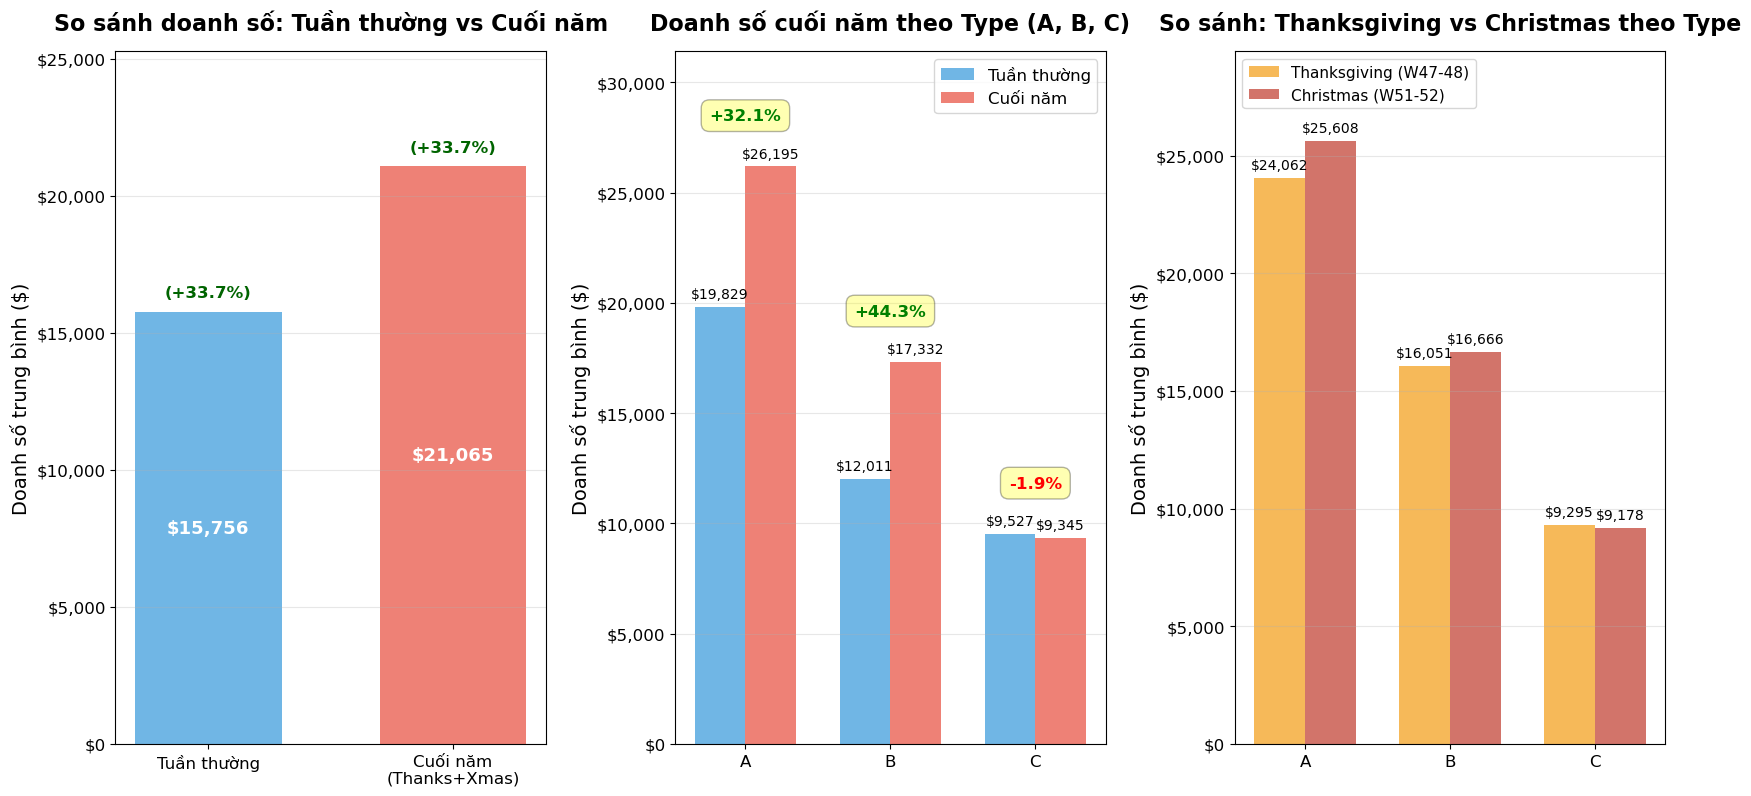

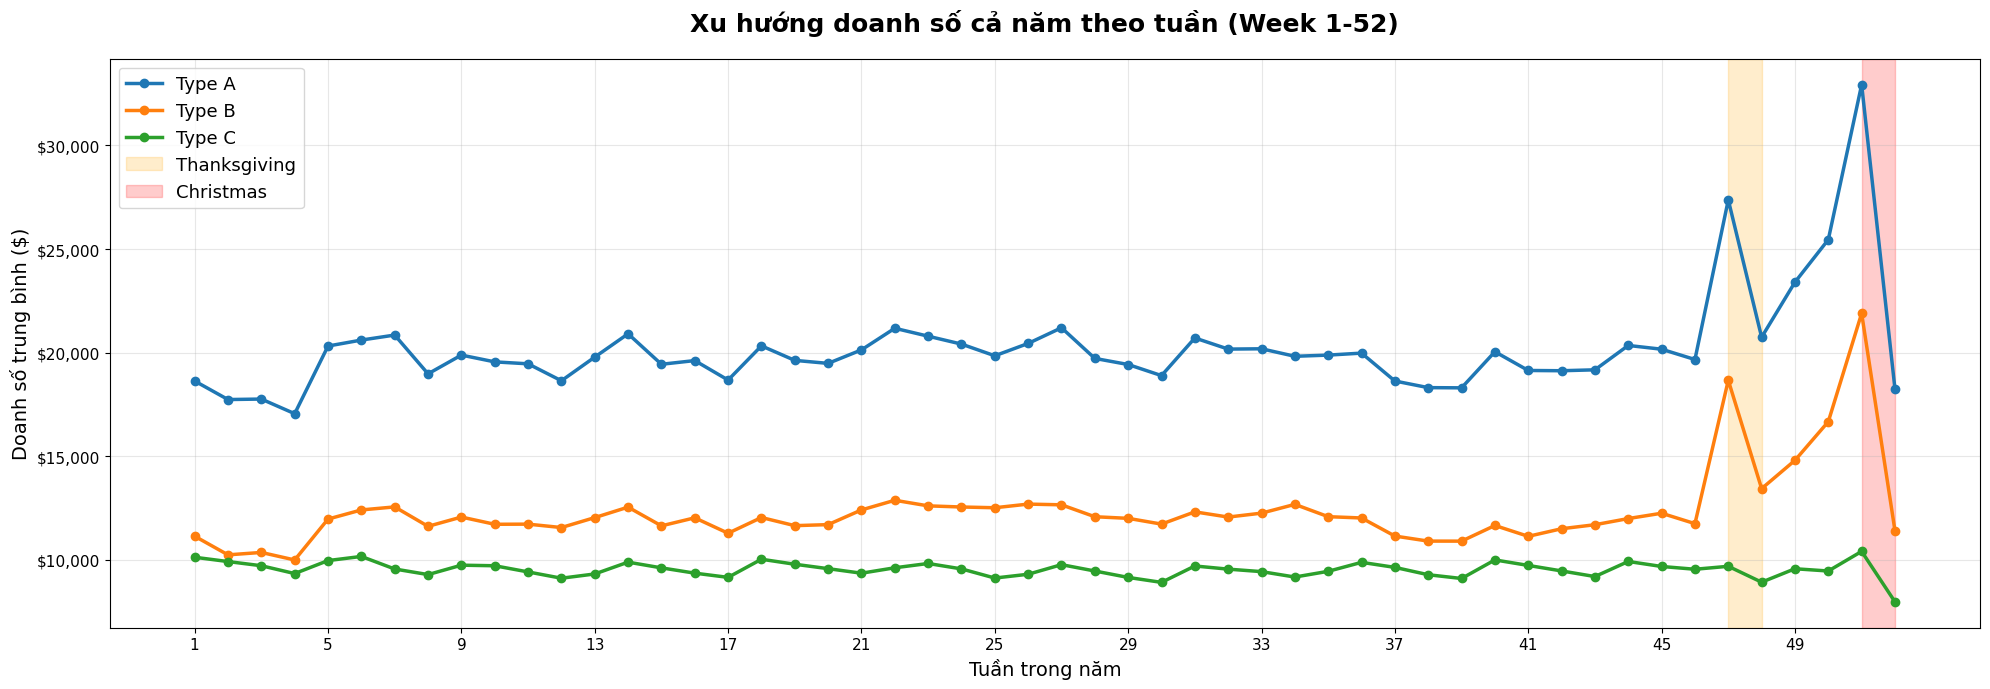

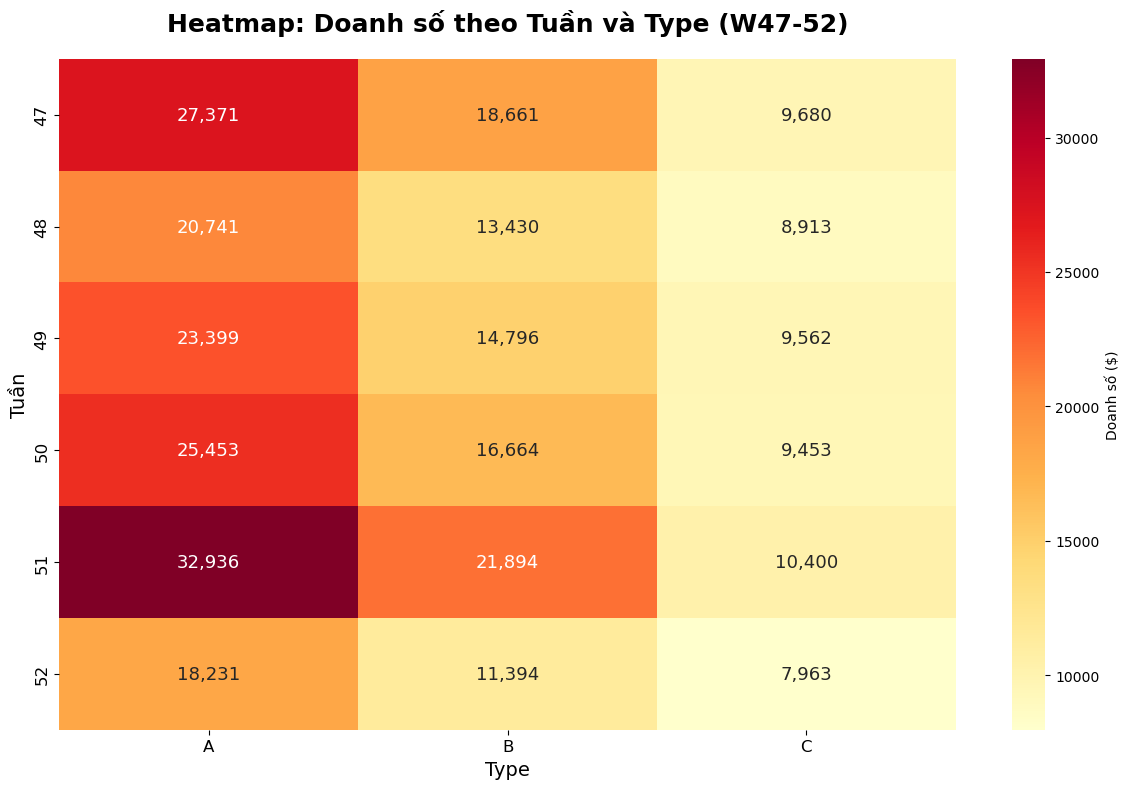


KẾT LUẬN

✓ Doanh số cuối năm TĂNG 33.70% so với tuần thường
  → Thanksgiving và Christmas là các mùa VÀNG cho Walmart

✓ TẤT CẢ 3 loại cửa hàng (A, B, C) đều TĂNG TRƯỞNG cuối năm:
  • Type A: +32.10%
  • Type B: +44.30%
  • Type C: -1.92%

✓ Christmas (W51-52) có doanh số CAO HƠN Thanksgiving (W47-48)
  → Mùa mua sắm Giáng sinh là đỉnh cao nhất trong năm

✓ Chiến lược kinh doanh:
  • Tăng cường tồn kho trước tuần 47
  • Bổ sung nhân sự trong tuần 47-52
  • Tập trung khuyến mãi vào giai đoạn này
  • Chuẩn bị logistics để đáp ứng nhu cầu cao


In [28]:
# PHÂN TÍCH: Doanh số cuối năm - Thanksgiving & Christmas

# print("="*80)
# print("DOANH SỐ CUỐI NĂM: TẠ ƠN & GIÁNG SINH")
# print("="*80)

# 1. Xác định các tuần đặc biệt
# Thanksgiving: tuần 47-48 (tháng 11)
# Christmas: tuần 51-52 (tháng 12)
walmart_data_train['Is_EndOfYear'] = (
    ((walmart_data_train['Month'] == 11) & (walmart_data_train['Week'].isin([47, 48]))) |
    ((walmart_data_train['Month'] == 12) & (walmart_data_train['Week'].isin([51, 52])))
)

# 2. Thống kê tổng quan
# print("\nThống kê doanh số cuối năm:")
endyear_stats = walmart_data_train.groupby('Is_EndOfYear')['Weekly_Sales'].agg(['mean', 'median', 'sum', 'count'])
endyear_stats.index = ['Tuần thường', 'Cuối năm (Thanks+Xmas)']
# print(endyear_stats)

normal_mean = endyear_stats.loc['Tuần thường', 'mean']
endyear_mean = endyear_stats.loc['Cuối năm (Thanks+Xmas)', 'mean']
increase_pct = ((endyear_mean - normal_mean) / normal_mean) * 100

# print(f"\nTăng trưởng: {increase_pct:+.2f}%")

# 3. Phân tích theo Type
# print("\n" + "-"*80)
# print("Doanh số cuối năm theo Type:")
type_endyear = walmart_data_train.groupby(['Type', 'Is_EndOfYear'])['Weekly_Sales'].mean().unstack()
type_endyear.columns = ['Tuần thường', 'Cuối năm']
type_endyear['Tăng trưởng (%)'] = ((type_endyear['Cuối năm'] - type_endyear['Tuần thường']) / type_endyear['Tuần thường'] * 100).round(2)
# print(type_endyear)

# 4. Phân tích theo tháng (Nov vs Dec)
# print("\n" + "-"*80)
# print("So sánh Tháng 11 (Thanksgiving) vs Tháng 12 (Christmas):")
holiday_months = walmart_data_train[walmart_data_train['Month'].isin([11, 12])].groupby(['Month', 'Type'])['Weekly_Sales'].mean().unstack(level=1)
holiday_months.index = ['Tháng 11 (Thanksgiving)', 'Tháng 12 (Christmas)']
# print(holiday_months)
# 5. Phân tích theo tuần cụ thể
# print("\n" + "-"*80)
# print("Doanh số theo tuần cuối năm (Week 47-52):")
weekly_endyear = walmart_data_train[walmart_data_train['Week'].isin([47, 48, 49, 50, 51, 52])].groupby(['Week', 'Type'])['Weekly_Sales'].mean().unstack(level=1)
weekly_endyear.index = [f'Tuần {int(w)}' for w in weekly_endyear.index]
# print(weekly_endyear)

# 6. Top stores cuối năm
# print("\n" + "-"*80)
# print("Top 10 cửa hàng có doanh số cao nhất cuối năm:")
top_endyear_stores = walmart_data_train[walmart_data_train['Is_EndOfYear'] == True].groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False).head(10)
# print(top_endyear_stores)

# VISUALIZATION - Tách thành 3 figure riêng biệt để dễ nhìn

# ========== FIGURE 1: Bar Charts So Sánh ==========
fig1 = plt.figure(figsize=(20, 9))
gs1 = fig1.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

# Chart 1.1: So sánh tổng quan
ax1 = fig1.add_subplot(gs1[0, 0])
bars = ax1.bar(['Tuần thường', 'Cuối năm\n(Thanks+Xmas)'], 
               [normal_mean, endyear_mean],
               color=['#3498db', '#e74c3c'], alpha=0.7, width=0.6)
ax1.set_title('So sánh doanh số: Tuần thường vs Cuối năm', 
             fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('Doanh số trung bình ($)', fontsize=14)
ax1.grid(axis='y', alpha=0.3)
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax1.tick_params(axis='both', labelsize=12)

# Tăng limit trục y để có không gian cho text
y_max = max(normal_mean, endyear_mean)
ax1.set_ylim(0, y_max * 1.20)

for bar, val in zip(bars, [normal_mean, endyear_mean]):
    # Hiển thị giá trị bên trong cột (ở giữa)
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.5,
            f'${val:,.0f}', 
            ha='center', va='center', fontsize=13, fontweight='bold', color='white')
    # Hiển thị phần trăm ở trên cột
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_max * 0.02,
            f'({increase_pct:+.1f}%)', 
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='darkgreen')

# Chart 1.2: So sánh theo Type
ax2 = fig1.add_subplot(gs1[0, 1])
x = np.arange(len(type_endyear))
width = 0.35
bars1 = ax2.bar(x - width/2, type_endyear['Tuần thường'], 
               width, label='Tuần thường', color='#3498db', alpha=0.7)
bars2 = ax2.bar(x + width/2, type_endyear['Cuối năm'], 
               width, label='Cuối năm', color='#e74c3c', alpha=0.7)

ax2.set_title('Doanh số cuối năm theo Type (A, B, C)', fontsize=16, fontweight='bold', pad=15)
ax2.set_ylabel('Doanh số trung bình ($)', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(type_endyear.index, fontsize=12)
ax2.legend(fontsize=12, loc='upper right')
ax2.grid(axis='y', alpha=0.3)
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax2.tick_params(axis='y', labelsize=12)

# Tăng limit trục y
y_max2 = max(type_endyear['Cuối năm'].max(), type_endyear['Tuần thường'].max())
ax2.set_ylim(0, y_max2 * 1.20)

# Thêm giá trị trên mỗi cột
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, height + y_max2 * 0.01,
                f'${height:,.0f}', 
                ha='center', va='bottom', fontsize=10)

# Thêm phần trăm tăng trưởng ở trên cùng
for i, pct in enumerate(type_endyear['Tăng trưởng (%)']):
    max_height = max(bars1[i].get_height(), bars2[i].get_height())
    ax2.text(i, max_height + y_max2 * 0.08, f'{pct:+.1f}%', 
            ha='center', fontsize=12, fontweight='bold', 
            color='green' if pct > 0 else 'red',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

# Chart 1.3: So sánh Thanksgiving vs Christmas
ax3 = fig1.add_subplot(gs1[0, 2])
thanksgiving_weeks = walmart_data_train[walmart_data_train['Week'].isin([47, 48])]
christmas_weeks = walmart_data_train[walmart_data_train['Week'].isin([51, 52])]

thanks_by_type = thanksgiving_weeks.groupby('Type')['Weekly_Sales'].mean()
xmas_by_type = christmas_weeks.groupby('Type')['Weekly_Sales'].mean()

x = np.arange(len(thanks_by_type))
width = 0.35
bars1 = ax3.bar(x - width/2, thanks_by_type.values, width, 
               label='Thanksgiving (W47-48)', color='#f39c12', alpha=0.7)
bars2 = ax3.bar(x + width/2, xmas_by_type.values, width, 
               label='Christmas (W51-52)', color='#c0392b', alpha=0.7)

ax3.set_title('So sánh: Thanksgiving vs Christmas theo Type', fontsize=16, fontweight='bold', pad=15)
ax3.set_ylabel('Doanh số trung bình ($)', fontsize=14)
ax3.set_xticks(x)
ax3.set_xticklabels(thanks_by_type.index, fontsize=12)
ax3.legend(fontsize=11, loc='upper left')
ax3.grid(axis='y', alpha=0.3)
ax3.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax3.tick_params(axis='y', labelsize=12)

# Tăng limit trục y
y_max3 = max(thanks_by_type.max(), xmas_by_type.max())
ax3.set_ylim(0, y_max3 * 1.15)

# Thêm giá trị trên mỗi cột với khoảng cách phù hợp
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + y_max3 * 0.01,
                f'${height:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# ========== FIGURE 2: Line Chart Xu Hướng ==========
fig2 = plt.figure(figsize=(20, 7))

weeks_to_plot = list(range(1, 53))
for store_type in ['A', 'B', 'C']:
    type_data = walmart_data_train[walmart_data_train['Type'] == store_type]
    weekly_data = type_data[type_data['Week'].isin(weeks_to_plot)].groupby('Week')['Weekly_Sales'].mean()
    plt.plot(weekly_data.index, weekly_data.values, marker='o', linewidth=2.5, 
            markersize=6, label=f'Type {store_type}')

# Đánh dấu các tuần đặc biệt
plt.axvspan(47, 48, alpha=0.2, color='orange', label='Thanksgiving')
plt.axvspan(51, 52, alpha=0.2, color='red', label='Christmas')

plt.title('Xu hướng doanh số cả năm theo tuần (Week 1-52)', 
         fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Tuần trong năm', fontsize=14)
plt.ylabel('Doanh số trung bình ($)', fontsize=14)
plt.xticks(range(1, 53, 4), fontsize=11)
plt.yticks(fontsize=11)
plt.legend(loc='upper left', fontsize=13)
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

# ========== FIGURE 3: Heatmap ==========
fig3 = plt.figure(figsize=(12, 8))

heatmap_data = walmart_data_train[walmart_data_train['Week'].isin(range(47, 53))].pivot_table(
    values='Weekly_Sales', index='Week', columns='Type', aggfunc='mean'
)
sns.heatmap(heatmap_data, annot=True, fmt=',.0f', cmap='YlOrRd', 
           cbar_kws={'label': 'Doanh số ($)'}, annot_kws={'fontsize': 13})
plt.title('Heatmap: Doanh số theo Tuần và Type (W47-52)', 
         fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Type', fontsize=14)
plt.ylabel('Tuần', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KẾT LUẬN")
print("="*80)
print(f"\n✓ Doanh số cuối năm TĂNG {increase_pct:.2f}% so với tuần thường")
print(f"  → Thanksgiving và Christmas là các mùa VÀNG cho Walmart")

print(f"\n✓ TẤT CẢ 3 loại cửa hàng (A, B, C) đều TĂNG TRƯỞNG cuối năm:")
for store_type in ['A', 'B', 'C']:
    pct = type_endyear.loc[store_type, 'Tăng trưởng (%)']
    print(f"  • Type {store_type}: {pct:+.2f}%")

print(f"\n✓ Christmas (W51-52) có doanh số CAO HƠN Thanksgiving (W47-48)")
print(f"  → Mùa mua sắm Giáng sinh là đỉnh cao nhất trong năm")

print(f"\n✓ Chiến lược kinh doanh:")
print(f"  • Tăng cường tồn kho trước tuần 47")
print(f"  • Bổ sung nhân sự trong tuần 47-52")
print(f"  • Tập trung khuyến mãi vào giai đoạn này")
print(f"  • Chuẩn bị logistics để đáp ứng nhu cầu cao")

**Nhận xét:**
- Theo như nhận định ở phân tích mô tả, các tuần cuối năm thường vào các dịp lễ tạ ơn (27/11) và giáng sinh (25/12) điều đó làm nhu cầu mua hàng ở khách hàng gia tăng. Cho nên các tuần cuối năm sẽ nhỉnh về doanh số hơn là các tuần thường.
- Đối với type, do sự phân bố không đồng đều điều này làm typeA có mức doanh số vào cuối năm tăng (32.1%) và typeB (44.3%), tuy nhiên typeC ở mức báo động (-1.9%). Điều này cho thấy sự phân bố quyết định nhiều về doanh số mua bán hay nói cách khác là cần chú trọng về Dept và Store hơn là các cột kinh tế vĩ mô khác.
- Ngoài ra sự gia tăng ở các tuần cuối năm từ 47-48 (thanksgiving) và 51-52 (christmas) cho thấy 2 ngày lễ này ảnh hướng đến nhu cầu mua sắm của khách hàng cao.

#### **3) Chỉ số giá tiêu dùng (CPI) qua các năm thay đổi như thế nào, có tác động khác biệt như thế nào đối với các nhóm cửa hàng không?**

C:\Users\luong\AppData\Local\Temp\ipykernel_17700\2346804353.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cpi_corr_by_type = walmart_data_train.groupby('Type').apply(


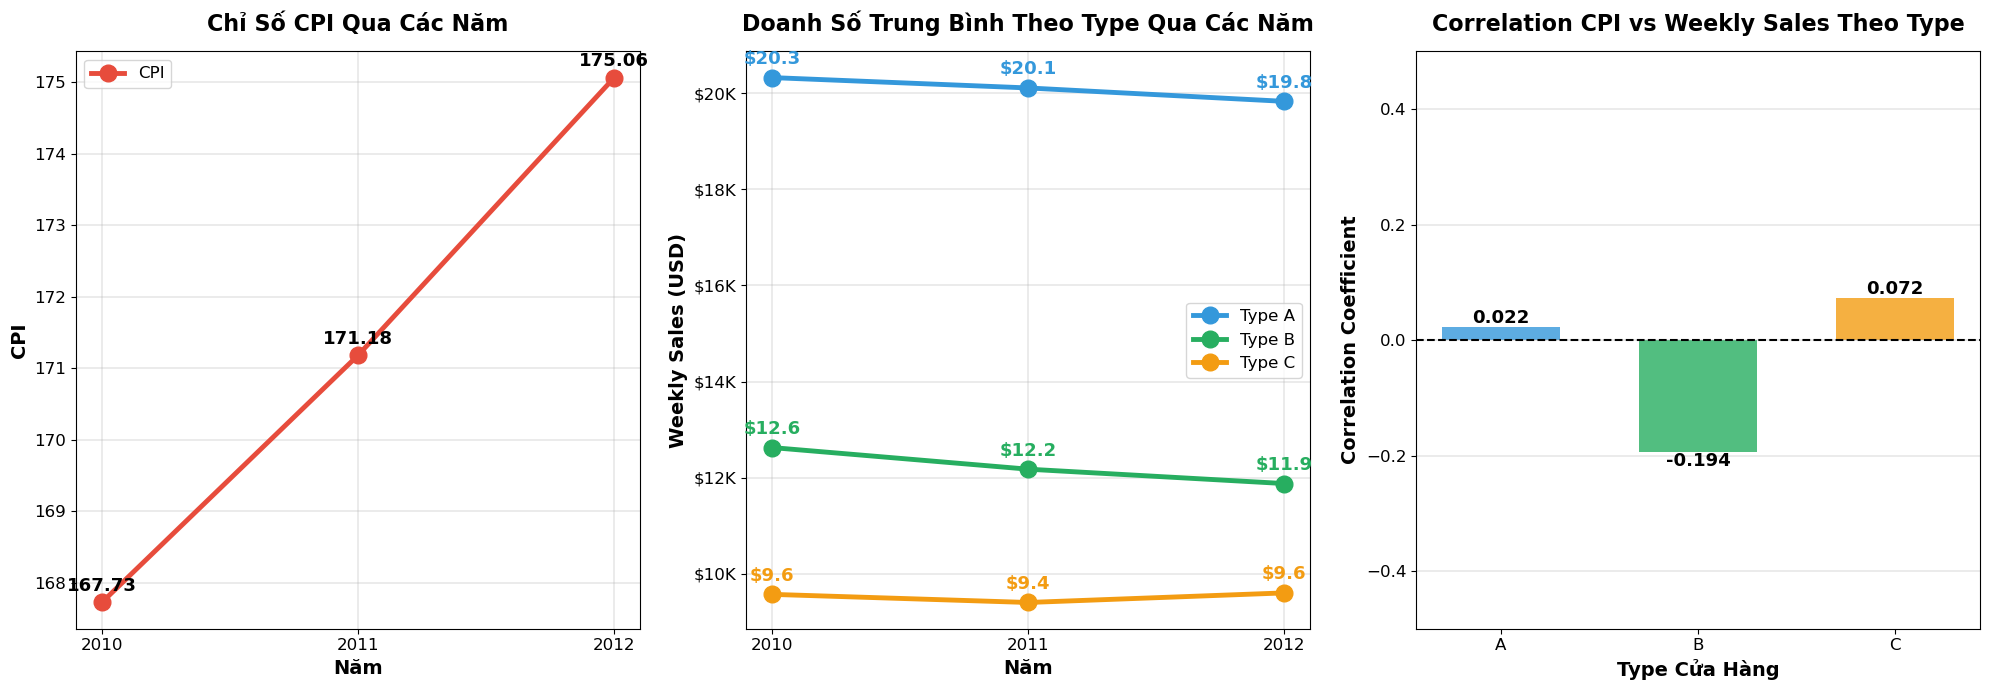

In [29]:
# Phân tích CPI qua các năm và tác động đến các nhóm cửa hàng

# 1. Tính CPI trung bình theo năm
yearly_cpi = walmart_data_train.groupby('Year')['CPI'].mean()

# 2. Tính doanh số trung bình theo Type và Year
type_year_sales = walmart_data_train.groupby(['Type', 'Year'])['Weekly_Sales'].mean().unstack()

# 3. Tính CPI trung bình theo Type và Year
type_year_cpi = walmart_data_train.groupby(['Type', 'Year'])['CPI'].mean().unstack()

# 4. Tính correlation CPI vs Weekly_Sales theo Type
cpi_corr_by_type = walmart_data_train.groupby('Type').apply(
    lambda x: x['CPI'].corr(x['Weekly_Sales'])
)

# 5. Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Chart 1: CPI qua các năm
ax1 = axes[0]
ax1.plot(yearly_cpi.index, yearly_cpi.values, marker='o', linewidth=3.5, 
         markersize=12, color='#e74c3c', label='CPI')
ax1.set_title('Chỉ Số CPI Qua Các Năm', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Năm', fontsize=14, fontweight='bold')
ax1.set_ylabel('CPI', fontsize=14, fontweight='bold')
ax1.set_xticks(yearly_cpi.index)
ax1.set_xticklabels([int(year) for year in yearly_cpi.index], fontsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.grid(alpha=0.3, linewidth=1.2)
ax1.legend(fontsize=12)
for i, val in enumerate(yearly_cpi.values):
    ax1.text(yearly_cpi.index[i], val + 0.1, f'{val:.2f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

# Chart 2: Doanh số theo Type qua các năm
ax2 = axes[1]
colors = ['#3498db', '#27ae60', '#f39c12']
for idx, store_type in enumerate(['A', 'B', 'C']):
    values = type_year_sales.loc[store_type]
    ax2.plot(values.index, values.values, marker='o', linewidth=3.5, 
             markersize=12, label=f'Type {store_type}', color=colors[idx])
    # Thêm text hiển thị giá trị trên mỗi điểm với khoảng cách
    for year, value in zip(values.index, values.values):
        ax2.text(year, value + 200, f'${value/1000:.1f}', 
                ha='center', va='bottom', fontsize=13, fontweight='bold', 
                color=colors[idx])
ax2.set_title('Doanh Số Trung Bình Theo Type Qua Các Năm', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('Năm', fontsize=14, fontweight='bold')
ax2.set_ylabel('Weekly Sales (USD)', fontsize=14, fontweight='bold')
ax2.set_xticks(type_year_sales.columns)
ax2.set_xticklabels([int(year) for year in type_year_sales.columns], fontsize=12)
ax2.tick_params(axis='y', labelsize=12)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
ax2.legend(fontsize=12)
ax2.grid(alpha=0.3, linewidth=1.2)

# Chart 3: Correlation CPI vs Sales theo Type
ax3 = axes[2]
bars = ax3.bar(cpi_corr_by_type.index, cpi_corr_by_type.values, 
               color=['#3498db', '#27ae60', '#f39c12'], alpha=0.8, width=0.6)
ax3.set_title('Correlation CPI vs Weekly Sales Theo Type', fontsize=16, fontweight='bold', pad=15)
ax3.set_xlabel('Type Cửa Hàng', fontsize=14, fontweight='bold')
ax3.set_ylabel('Correlation Coefficient', fontsize=14, fontweight='bold')
ax3.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
ax3.set_ylim(-0.5, 0.5)
ax3.tick_params(axis='both', labelsize=12)
ax3.grid(axis='y', alpha=0.3, linewidth=1.2)

for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom' if height > 0 else 'top',
            fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:**

Chỉ số CPI trung bình tăng từ 167.73 vào năm 2010 lên 175.06 vào năm 2012, tương ứng mức tăng tổng cộng 4.37% trong cả giai đoạn hai năm. 

Khi quy đổi về mức tăng bình quân hàng năm (annualized), tốc độ tăng tương đương khoảng 2.16%/năm. Do đó, mặc dù có sự tăng giá — tức là tồn tại lạm phát — nhưng với tốc độ bình quân khoảng 2.16%/năm, giai đoạn 2010–2012 thuộc nhóm lạm phát thấp và tương đối ổn định, phù hợp với mục tiêu lạm phát gần 2%/năm mà Cục Dự trữ Liên bang Hoa Kỳ (Federal Reserve) thường tham chiếu. 


## **IV. TIỀN XỬ LÝ**

### **1. Missing value**

#### **1.1 Train**

In [30]:
# train
n_rows = len(walmart_data_train)
n_duplicated = walmart_data_train.duplicated().sum()

missing_cols = (
    walmart_data_train.isna().sum()
      .loc[lambda s: s > 0]  # lọc cột có thiếu
      .sort_values(ascending=False)
)

summary = (
    pd.DataFrame({
        "column": missing_cols.index,
        "missing_count": missing_cols.values,
        "missing_pct": (missing_cols.values / n_rows * 100).round(2)
    })
)

# Nếu muốn hiển thị % kèm dấu %
summary["missing_pct"] = summary["missing_pct"].astype(str) + "%"

print("Các cột có giá trị thiếu:")
display.display(summary)

print(f'Số dòng trùng: {n_duplicated}')

if n_duplicated > 0:
    n_duplicated_rows = walmart_data_train[walmart_data_train.duplicated(keep=False)]
    display.display(n_duplicated_rows)

Các cột có giá trị thiếu:


,column,missing_count,missing_pct
0,MarkDown2,310322,73.61%
1,MarkDown4,286603,67.98%
2,MarkDown3,284479,67.48%
3,MarkDown1,270889,64.26%
4,MarkDown5,270138,64.08%
5,Temp_Range,159,0.04%


Số dòng trùng: 0


Trong phân tích trước đó, trong toàn bộ dữ liệu các cột Markdown từ 1-5 đều bị thiếu dữ liệu và bị thiếu rất nhiều, tuy nhiên thiếu có chủ đích nên sẽ thay các giá trị thiếu bằng 0.

In [31]:
# Train
# Xử lý giá trị thiếu ở các cột MarkDown bằng 0
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Fill giá trị thiếu bằng 0
walmart_data_train[markdown_cols] = walmart_data_train[markdown_cols].fillna(0)

# Hiển thị kết quả sau khi xử lý
print("\nSố lượng giá trị thiếu SAU khi xử lý:")
for col in markdown_cols:
    missing_count = walmart_data_train[col].isna().sum()
    print(f"  {col}: {missing_count}")


Số lượng giá trị thiếu SAU khi xử lý:
  MarkDown1: 0
  MarkDown2: 0
  MarkDown3: 0
  MarkDown4: 0
  MarkDown5: 0


In [32]:
# train
print(walmart_data_train[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']])

        MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5
0            0.00       0.00       0.00       0.00       0.00
1            0.00       0.00       0.00       0.00       0.00
2            0.00       0.00       0.00       0.00       0.00
3            0.00       0.00       0.00       0.00       0.00
4            0.00       0.00       0.00       0.00       0.00
...           ...        ...        ...        ...        ...
421565    4556.61      20.64       1.50    1601.01    3288.25
421566    5046.74       0.00      18.82    2253.43    2340.01
421567    1956.28       0.00       7.89     599.32    3990.54
421568    2004.02       0.00       3.18     437.73    1537.49
421569    4018.91      58.08     100.00     211.94     858.33

[421570 rows x 5 columns]


In [33]:
# train
walmart_data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Type          421570 non-null  object        
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     421570 non-null  float64       
 10  MarkDown2     421570 non-null  float64       
 11  MarkDown3     421570 non-null  float64       
 12  MarkDown4     421570 non-null  float64       
 13  MarkDown5     421570 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421

#### **1.2 Test**

In [34]:
# test
n_rows = len(walmart_data_test)
n_duplicated = walmart_data_test.duplicated().sum()

missing_cols = (
    walmart_data_test.isna().sum()
      .loc[lambda s: s > 0]  # lọc cột có thiếu
      .sort_values(ascending=False)
)

summary = (
    pd.DataFrame({
        "column": missing_cols.index,
        "missing_count": missing_cols.values,
        "missing_pct": (missing_cols.values / n_rows * 100).round(2)
    })
)

# Nếu muốn hiển thị % kèm dấu %
summary["missing_pct"] = summary["missing_pct"].astype(str) + "%"

print("Các cột có giá trị thiếu:")
display.display(summary)

print(f'Số dòng trùng: {n_duplicated}')

if n_duplicated > 0:
    n_duplicated_rows = walmart_data_test[walmart_data_test.duplicated(keep=False)]
    display.display(n_duplicated_rows)

Các cột có giá trị thiếu:


,column,missing_count,missing_pct
0,CPI,38162,33.17%
1,Unemployment,38162,33.17%
2,MarkDown2,28627,24.88%
3,MarkDown4,12888,11.2%
4,MarkDown3,9829,8.54%
5,MarkDown1,149,0.13%


Số dòng trùng: 0


In [35]:
# test
# Xử lý giá trị thiếu ở các cột MarkDown bằng 0
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', "CPI", "Unemployment"]

# Fill giá trị thiếu bằng 0
walmart_data_test[markdown_cols] = walmart_data_test[markdown_cols].fillna(0)

# Hiển thị kết quả sau khi xử lý
print("\nSố lượng giá trị thiếu SAU khi xử lý:")
for col in markdown_cols:
    missing_count = walmart_data_test[col].isna().sum()
    print(f"  {col}: {missing_count}")


Số lượng giá trị thiếu SAU khi xử lý:
  MarkDown1: 0
  MarkDown2: 0
  MarkDown3: 0
  MarkDown4: 0
  CPI: 0
  Unemployment: 0


In [36]:
# test
print(walmart_data_train[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4']])

        MarkDown1  MarkDown2  MarkDown3  MarkDown4
0            0.00       0.00       0.00       0.00
1            0.00       0.00       0.00       0.00
2            0.00       0.00       0.00       0.00
3            0.00       0.00       0.00       0.00
4            0.00       0.00       0.00       0.00
...           ...        ...        ...        ...
421565    4556.61      20.64       1.50    1601.01
421566    5046.74       0.00      18.82    2253.43
421567    1956.28       0.00       7.89     599.32
421568    2004.02       0.00       3.18     437.73
421569    4018.91      58.08     100.00     211.94

[421570 rows x 4 columns]


In [37]:
#test
walmart_data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         115064 non-null  int64         
 1   Dept          115064 non-null  int64         
 2   Date          115064 non-null  datetime64[ns]
 3   IsHoliday     115064 non-null  bool          
 4   Type          115064 non-null  object        
 5   Size          115064 non-null  int64         
 6   Temperature   115064 non-null  float64       
 7   Fuel_Price    115064 non-null  float64       
 8   MarkDown1     115064 non-null  float64       
 9   MarkDown2     115064 non-null  float64       
 10  MarkDown3     115064 non-null  float64       
 11  MarkDown4     115064 non-null  float64       
 12  MarkDown5     115064 non-null  float64       
 13  CPI           115064 non-null  float64       
 14  Unemployment  115064 non-null  float64       
 15  Year          115

**Nhận xét:**

Dữ liệu sau khi xử lý không còn giá trị thiếu.

### **2. Change Data in feature columns**

Tất cả các cột đều có dữ liệu số (int, float) tuy nhiên có các cột $Isholiday$ và $Type$ cần điều chỉnh về dạng số để thực hiện xây dựng mô hình.

In [38]:
# change Type columns with A = 1, B = 2 and C = 3
def type_count(x): 
    if x == 'A':
        return 1
    elif x == 'B':
        return 2
    return 3

In [39]:
# change Type columns with True = 1, Flase = 0
def paron(x):
    if x == False:
        return 0
    return 1

#### **2.1 Train**

In [40]:
#Train
actualScore_train = walmart_data_train['Type']
type_coun = actualScore_train.map(type_count)
walmart_data_train['Types'] = type_coun

In [41]:
#Train.csv
actualScore_train = walmart_data_train['IsHoliday']
posiveNegave = actualScore_train.map(paron)
walmart_data_train['IsHoliday'] = posiveNegave
print("Shape of train_with_feature: ", walmart_data_train.shape)
walmart_data_train.head(3)

Shape of train_with_feature:  (421570, 26)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,Year,Month,Week,Quarter,Temp_Range,Season,Unemp_Level,Fuel_Level,Is_EndOfYear,Types
0,1,1,2010-02-05,24924.50,0,A,151315,42.31,2.572,0.0,...,2010,2,5,1,Mát (40-60°F),Đông,Cao (8-10%),Thấp (<$2.8),False,1
1,1,1,2010-02-12,46039.49,1,A,151315,38.51,2.548,0.0,...,2010,2,6,1,Lạnh (<40°F),Đông,Cao (8-10%),Thấp (<$2.8),False,1
2,1,1,2010-02-19,41595.55,0,A,151315,39.93,2.514,0.0,...,2010,2,7,1,Lạnh (<40°F),Đông,Cao (8-10%),Thấp (<$2.8),False,1


In [42]:
# train
walmart_data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  int64         
 5   Type          421570 non-null  object        
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     421570 non-null  float64       
 10  MarkDown2     421570 non-null  float64       
 11  MarkDown3     421570 non-null  float64       
 12  MarkDown4     421570 non-null  float64       
 13  MarkDown5     421570 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421

#### **2.2. Test**

In [43]:
#Test.csv
actualScore_test = walmart_data_test['Type']
type_coun = actualScore_test.map(type_count)
walmart_data_test['Types'] = type_coun

In [44]:
#test.csv
actualScore_test = walmart_data_test['IsHoliday']
posiveNegave = actualScore_test.map(paron)
walmart_data_test['IsHoliday'] = posiveNegave
print("Shape of train_with_feature: ", walmart_data_test.shape)
walmart_data_test.head(3)

Shape of train_with_feature:  (115064, 20)


,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Quarter,Types
0,1,1,2012-11-02,0,A,151315,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,2012,11,44,4,1
1,1,1,2012-11-09,0,A,151315,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,2012,11,45,4,1
2,1,1,2012-11-16,0,A,151315,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,2012,11,46,4,1


In [45]:
# test
walmart_data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         115064 non-null  int64         
 1   Dept          115064 non-null  int64         
 2   Date          115064 non-null  datetime64[ns]
 3   IsHoliday     115064 non-null  int64         
 4   Type          115064 non-null  object        
 5   Size          115064 non-null  int64         
 6   Temperature   115064 non-null  float64       
 7   Fuel_Price    115064 non-null  float64       
 8   MarkDown1     115064 non-null  float64       
 9   MarkDown2     115064 non-null  float64       
 10  MarkDown3     115064 non-null  float64       
 11  MarkDown4     115064 non-null  float64       
 12  MarkDown5     115064 non-null  float64       
 13  CPI           115064 non-null  float64       
 14  Unemployment  115064 non-null  float64       
 15  Year          115

### **3. Aggeration (tổng hợp)**

Các biến Temperature, Fuel_Price, CPI và Unemployment là các chỉ số vĩ mô hoặc môi trường mang tính đặc trưng cho từng khu vực theo từng tuần. Do đó khi tiến hành tổng hợp dữ liệu theo cấp độ Store–Week hoặc Store–Dept–Week, các giá trị của những biến này thường trùng lặp. 

Vì vậy, việc sử dụng hàm trung bình (mean) là phù hợp để tạo ra một giá trị đại diện duy nhất cho mỗi tuần, đồng thời giúp dữ liệu gọn hơn, tránh trùng lặp và đảm bảo tính ổn định khi đưa vào mô hình phân tích

#### **3.1 Train**

In [46]:
walmart_data_train['Fuel_Price_mean'] = walmart_data_train['Fuel_Price'].mean()
walmart_data_train['CPI_mean'] = walmart_data_train['CPI'].mean()
walmart_data_train['Tem_mean'] = walmart_data_train['Temperature'].mean()
walmart_data_train['Unem_mean'] = walmart_data_train['Unemployment'].mean()
walmart_data_train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,Temp_Range,Season,Unemp_Level,Fuel_Level,Is_EndOfYear,Types,Fuel_Price_mean,CPI_mean,Tem_mean,Unem_mean
0,1,1,2010-02-05,24924.50,0,A,151315,42.31,2.572,0.0,...,Mát (40-60°F),Đông,Cao (8-10%),Thấp (<$2.8),False,1,3.361027,171.201947,60.090059,7.960289
1,1,1,2010-02-12,46039.49,1,A,151315,38.51,2.548,0.0,...,Lạnh (<40°F),Đông,Cao (8-10%),Thấp (<$2.8),False,1,3.361027,171.201947,60.090059,7.960289
2,1,1,2010-02-19,41595.55,0,A,151315,39.93,2.514,0.0,...,Lạnh (<40°F),Đông,Cao (8-10%),Thấp (<$2.8),False,1,3.361027,171.201947,60.090059,7.960289
3,1,1,2010-02-26,19403.54,0,A,151315,46.63,2.561,0.0,...,Mát (40-60°F),Đông,Cao (8-10%),Thấp (<$2.8),False,1,3.361027,171.201947,60.090059,7.960289
4,1,1,2010-03-05,21827.90,0,A,151315,46.50,2.625,0.0,...,Mát (40-60°F),Xuân,Cao (8-10%),Thấp (<$2.8),False,1,3.361027,171.201947,60.090059,7.960289


#### **3.2 Test**

In [47]:
walmart_data_test['Fuel_Price_mean'] = walmart_data_test['Fuel_Price'].mean()
walmart_data_test['CPI_mean'] = walmart_data_test['CPI'].mean()
walmart_data_test['Tem_mean'] = walmart_data_test['Temperature'].mean()
walmart_data_test['Unem_mean'] = walmart_data_test['Unemployment'].mean()
walmart_data_test.head()

,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,Unemployment,Year,Month,Week,Quarter,Types,Fuel_Price_mean,CPI_mean,Tem_mean,Unem_mean
0,1,1,2012-11-02,0,A,151315,55.32,3.386,6766.44,5147.70,...,6.573,2012,11,44,4,1,3.581546,118.270541,53.941804,4.590657
1,1,1,2012-11-09,0,A,151315,61.24,3.314,11421.32,3370.89,...,6.573,2012,11,45,4,1,3.581546,118.270541,53.941804,4.590657
2,1,1,2012-11-16,0,A,151315,52.92,3.252,9696.28,292.10,...,6.573,2012,11,46,4,1,3.581546,118.270541,53.941804,4.590657
3,1,1,2012-11-23,1,A,151315,56.23,3.211,883.59,4.17,...,6.573,2012,11,47,4,1,3.581546,118.270541,53.941804,4.590657
4,1,1,2012-11-30,0,A,151315,52.34,3.207,2460.03,0.00,...,6.573,2012,11,48,4,1,3.581546,118.270541,53.941804,4.590657


## **V. XÂY DỰNG MODEL**

Mặc dù phân tích EDA cho thấy Store, Dept và Date là các yếu tố ảnh hưởng mạnh nhất đến doanh số, nhưng trong giai đoạn lựa chọn đặc trưng (Feature Engineering), nghiên cứu vẫn giữ lại toàn bộ các biến kinh tế, khuyến mãi và đặc tính cửa hàng. Điều này đảm bảo mô hình học được đầy đủ các tín hiệu yếu – mạnh khác nhau, từ đó nâng cao độ chính xác dự báo so với việc chỉ sử dụng các biến mạnh từ EDA.

### **1. Chosses Feature and target**

In [48]:
features_drop_train=['CPI','Unemployment','Fuel_Price','MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5', "Temp_Range", "Season", "Unemp_Level", "Fuel_Level", "Is_EndOfYear", "Type"]
features_drop_test=['CPI','Unemployment','Fuel_Price','MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5', "Type"]
train_final=walmart_data_train.drop(features_drop_train, axis=1)
test_final=walmart_data_test.drop(features_drop_test, axis=1)

In [49]:
#### train X= Exery thing except Weekly_Sales
train_X=train_final.drop(['Weekly_Sales','Date'], axis=1)

#### train Y= Only Weekly_Sales 
train_y=train_final['Weekly_Sales'] 
test_X=test_final.drop('Date',axis=1).copy()

train_X.shape, train_y.shape, test_X.shape

((421570, 14), (421570,), (115064, 14))

In [50]:
train_X.head(2)

,Store,Dept,IsHoliday,Size,Temperature,Year,Month,Week,Quarter,Types,Fuel_Price_mean,CPI_mean,Tem_mean,Unem_mean
0,1,1,0,151315,42.31,2010,2,5,1,1,3.361027,171.201947,60.090059,7.960289
1,1,1,1,151315,38.51,2010,2,6,1,1,3.361027,171.201947,60.090059,7.960289


In [51]:
test_X.head(2)

,Store,Dept,IsHoliday,Size,Temperature,Year,Month,Week,Quarter,Types,Fuel_Price_mean,CPI_mean,Tem_mean,Unem_mean
0,1,1,0,151315,55.32,2012,11,44,4,1,3.581546,118.270541,53.941804,4.590657
1,1,1,0,151315,61.24,2012,11,45,4,1,3.581546,118.270541,53.941804,4.590657


In [52]:
unie_columns = walmart_data_train["Weekly_Sales"].unique()
df_unie = pd.DataFrame(unie_columns, columns = ["Weekly_Sales"])
df_unie.head(2)

,Weekly_Sales
0,24924.50
1,46039.49


### **2. Model training**

Do số lượng dòng và số lượng cột trong bộ dữ liệu không quá lớn, đồng thời các biến dạng ID như Store, Dept, … có số lượng giá trị rất lớn, những biến này chỉ đóng vai trò phân biệt thực thể chứ không mang bản chất thông tin có thể suy luận theo tuyến tính. Khi được đưa trực tiếp vào các mô hình tuyến tính, các biến ID dễ khiến mô hình hiểu sai cấu trúc quan hệ, dẫn đến hiện tượng overfitting hoặc học nhầm các mẫu không có thật.

Vì lý do đó, để đảm bảo mô hình có khả năng xử lý tốt dữ liệu dạng phân loại có số lượng giá trị lớn, đồng thời duy trì được độ chính xác ổn định và khả năng khái quát hóa cao, ta nên ưu tiên sử dụng các mô hình phi tuyến như Random Forest Regressor.

Mà model RandomForest có ưu điểm nổi bật là:

- Không bị ảnh hưởng tiêu cực bởi các biến ID có nhiều giá trị.

- Tự động học được các quan hệ phi tuyến và tương tác phức tạp giữa các biến.

- Ổn định, ít nhạy cảm với nhiễu và không cần chuẩn hóa dữ liệu.

- Hoạt động tốt ngay cả khi có cả biến categorical (đã được encode) và numerical.

>Do đó, lựa chọn RandomForestRegressor là phù hợp và hợp lý trong bối cảnh cấu trúc dữ liệu của bài toán doanh số này.

In [53]:
from sklearn.model_selection import train_test_split
# Split train data thành train và validation
X_train, X_val, y_train, y_val = train_test_split(train_X, train_y, test_size=0.2, random_state=42)
# fit
clf_eval = RandomForestRegressor(n_estimators=100, random_state=42)
clf_eval.fit(X_train, y_train)
# Predict trên validation set
y_pred_val = clf_eval.predict(X_val)

### **3. Evaluation**

In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# evaluation
mae = mean_absolute_error(y_val, y_pred_val) #  Sai số tuyệt đối trung bình
mse = mean_squared_error(y_val, y_pred_val) # Sai số bình phương trung bình
rmse = np.sqrt(mse) # Căn bậc hai của MSE
r2 = r2_score(y_val, y_pred_val) # Hệ số xác định

# In kết quả đánh giá
print("ĐÁNH GIÁ MODEL RANDOM FOREST REGRESSOR")
print(f"Mean Absolute Error (MAE):     {mae:,.2f}")
print(f"Mean Squared Error (MSE):      {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score:                      {r2:.4f}")


ĐÁNH GIÁ MODEL RANDOM FOREST REGRESSOR
Mean Absolute Error (MAE):     1,403.44
Mean Squared Error (MSE):      13,212,209.97
Root Mean Squared Error (RMSE): 3,634.86
R² Score:                      0.9747


In [55]:
y_pred_test = clf_eval.predict(test_X)
# Tạo submission với dữ liệu đúng
submission = pd.DataFrame({
    "Id": walmart_data_test['Store'].astype(str) + '_' + 
          walmart_data_test['Dept'].astype(str) + '_' + 
          walmart_data_test['Date'].astype(str),
    "Weekly_Sales": y_pred_test 
})
                          
submission.head()

,Id,Weekly_Sales
0,1_1_2012-11-02,31812.2322
1,1_1_2012-11-09,19499.3646
2,1_1_2012-11-16,18424.2551
3,1_1_2012-11-23,19991.4099
4,1_1_2012-11-30,23306.2717


In [56]:
# Lưu file submission
submission.to_csv('dataset/submission.csv', index=False)
print("saved!!!")

saved!!!


### **5. Lưu Model bằng Joblib**

In [57]:
import joblib

# Lưu model đã train
joblib.dump(clf_eval, 'rf_walmart_model.pkl')

print("Đã lưu model: rf_walmart_model.pkl")
print(f"Load lại: loaded_model = joblib.load('rf_walmart_model.pkl')")

Đã lưu model: rf_walmart_model.pkl
Load lại: loaded_model = joblib.load('rf_walmart_model.pkl')


In [58]:
# # Định nghĩa các siêu tham số cần tìm kiếm
# param_grid = { 
#     "n_estimators": [500],           # Số cây trong rừng
#     "max_depth": [None, 20, 30],               # Độ sâu tối đa của cây
#     "min_samples_split": [2, 5, 10],           # Số mẫu tối thiểu để chia node
#     "min_samples_leaf": [1, 2, 4],             # Số mẫu tối thiểu ở node lá
#     "max_features": ["sqrt", "log2"]           # Số features xem xét khi chia
# }

In [59]:
# from sklearn.model_selection import GridSearchCV
# # Khởi tạo base model (REGRESSION, không phải classification)
# rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
# # Khởi tạo GridSearchCV
# grid_search = GridSearchCV(
#     estimator=rf_base,           # Model Random Forest Regressor
#     param_grid=param_grid,       # Grid các siêu tham số
#     cv=5,                        # 5-fold cross-validation
#     scoring='neg_mean_squared_error',  # Metric cho regression (càng gần 0 càng tốt)
#     n_jobs=-1,                   # Sử dụng tất cả CPU cores
#     verbose=2                    # Hiển thị tiến trình chi tiết
# )

# #fit
# grid_search.fit(X_train, y_train)

# print(f"\nSiêu tham số tốt nhất:")
# for param, value in grid_search.best_params_.items():
#     print(f"   • {param}: {value}")

# # Lưu model tốt nhất
# best_model = grid_search.best_estimator_

# # Đánh giá trên validation set
# y_pred_best = best_model.predict(X_val)
# mae_best = mean_absolute_error(y_val, y_pred_best)
# rmse_best = np.sqrt(mean_squared_error(y_val, y_pred_best))
# r2_best = r2_score(y_val, y_pred_best)

# print(f"\nHiệu suất trên Validation Set:")
# print(f"   • MAE:  {mae_best:,.2f}")
# print(f"   • RMSE: {rmse_best:,.2f}")
# print(f"   • R²:   {r2_best:.4f}")
# print("="*80)

# KẾT THÚC